In [262]:
import numpy as np
import pandas as pd
import os
import re
import tensorflow as tf
from threading import Thread
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import init_notebook_mode
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201, Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

init_notebook_mode(connected=True)

# Product Recommendations: Visually Similar Content Filtering using KNNs
- A recommender system, or a recommendation system, is a subclass of information filtering system that provide suggestions for items that are most pertinent to a particular user.Typically, the suggestions refer to various decision-making processes, such as what product to purchase, what music to listen to, or what online news to read. Recommender systems are particularly useful when an individual needs to choose an item from a potentially overwhelming number of items that a service may offer.
- Recommender Systems can be broadly classified into 3 types
    - Collaborative Filtering
    - Content-Based Filtering
    - Hybrid
- This notebook will demonstrate the Content-Based filtering, which are based on the description of an item and a profile of the user’s preferred choices. In a content-based recommendation system, features are used to describe the items, besides, a user profile is built to state the type of item this user likes. In other words, the algorithms try to recommend products that are similar to the ones that a user has liked in the past.
- However, we can use K-Nearest Neighbours algorithms to recommend products which have visually similar features, such as the ones you see in shopping websites **e.g. "Products that are similar to this"**

# EDA and Visualization
- Lets first merge the image data and product meta data to get the required dataset
- We will look at some of the categories and subcategories to understand which categories are more dominant

## Images Dataframe

In [263]:
images_df = pd.read_csv("../input/fashion-product-images-dataset/fashion-dataset/images.csv")

## Product Meta Data Dataframe

In [264]:
styles_df = pd.read_csv("../input/fashion-product-images-dataset/fashion-dataset/styles.csv", on_bad_lines='skip')

## Create Unique ID in both Dataframes

In [265]:
images_df['id'] = images_df['filename'].apply(lambda x: x.replace(".jpg","")).astype(int)

In [266]:
# images_df.head()
images_df['link'][0]

'http://assets.myntassets.com/v1/images/style/properties/7a5b82d1372a7a5c6de67ae7a314fd91_images.jpg'

In [267]:
# images_df['link'].head()

## Merging the Two Dataframes

In [268]:
data = styles_df.merge(images_df,on='id',how='left').reset_index(drop=True)
data['filename'] = data['filename'].apply(lambda x: os.path.join("../input/fashion-product-images-dataset/fashion-dataset/images/",x))

In [269]:
image_files = os.listdir("../input/fashion-product-images-dataset/fashion-dataset/images")

## Removing Products for which images are not present

In [270]:
data['file_found'] = data['id'].apply(lambda x: f"{x}.jpg" in image_files)

In [271]:
data = data[data['file_found']].reset_index(drop=True)

**EDA**

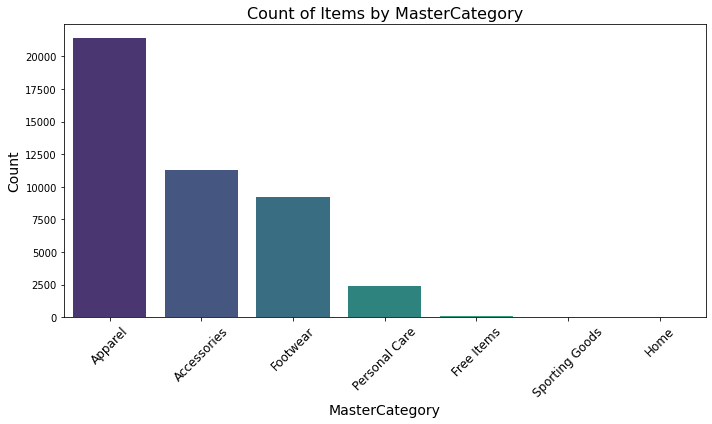

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of occurrences of each masterCategory
master_category_counts = data['masterCategory'].value_counts()

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=master_category_counts.index, y=master_category_counts.values, palette="viridis")
plt.title('Count of Items by MasterCategory', fontsize=16)
plt.xlabel('MasterCategory', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


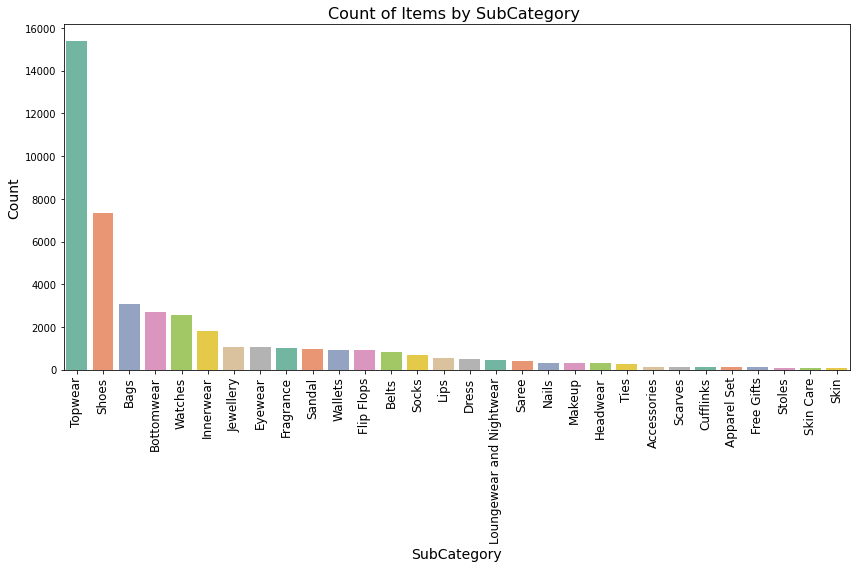

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of occurrences of each subCategory
sub_category_counts = data['subCategory'].value_counts()

# Filter subcategories with count greater than 10
filtered_sub_category_counts = sub_category_counts[sub_category_counts > 50]

# Plot the bar graph
plt.figure(figsize=(12, 8))
sns.barplot(x=filtered_sub_category_counts.index, y=filtered_sub_category_counts.values, palette="Set2")
plt.title('Count of Items by SubCategory ', fontsize=16)
plt.xlabel('SubCategory', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.tight_layout()
plt.show()


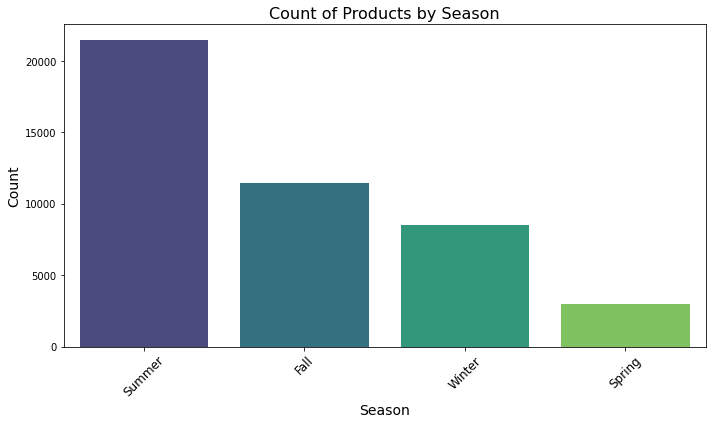

In [274]:
# Count the number of occurrences of each season
season_counts = data['season'].value_counts()

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette="viridis")
plt.title('Count of Products by Season', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


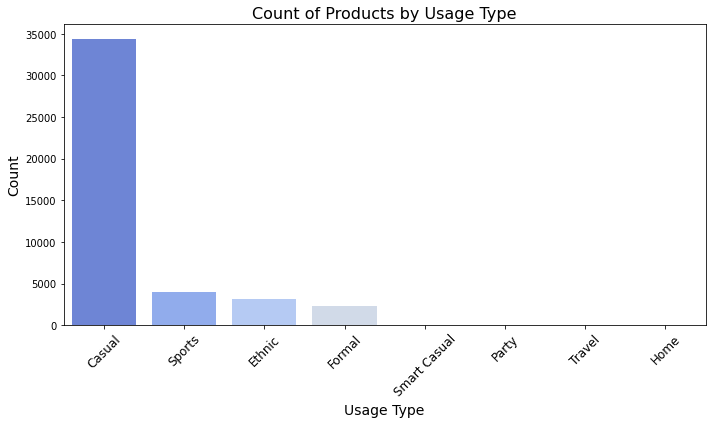

In [275]:
# Count the number of occurrences of each usage type
usage_counts = data['usage'].value_counts()

# Plot the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=usage_counts.index, y=usage_counts.values, palette="coolwarm")
plt.title('Count of Products by Usage Type', fontsize=16)
plt.xlabel('Usage Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


## Final Data

In [276]:
data.head()
new_data=data.copy()

In [277]:
# Apply a check to convert non-string types to an empty string or handle NaN values
data['gender'] = data['gender'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['masterCategory'] = data['masterCategory'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['subCategory'] = data['subCategory'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['articleType'] = data['articleType'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['baseColour'] = data['baseColour'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['season'] = data['season'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['usage'] = data['usage'].apply(lambda x: x.split() if isinstance(x, str) else [])
data['productDisplayName'] = data['productDisplayName'].apply(lambda x: x.split() if isinstance(x, str) else [])

In [278]:
data.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
filename               object
link                   object
file_found               bool
dtype: object

In [279]:

data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,file_found
0,15970,[Men],[Apparel],[Topwear],[Shirts],"[Navy, Blue]",[Fall],2011.0,[Casual],"[Turtle, Check, Men, Navy, Blue, Shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True
1,39386,[Men],[Apparel],[Bottomwear],[Jeans],[Blue],[Summer],2012.0,[Casual],"[Peter, England, Men, Party, Blue, Jeans]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True
2,59263,[Women],[Accessories],[Watches],[Watches],[Silver],[Winter],2016.0,[Casual],"[Titan, Women, Silver, Watch]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True
3,21379,[Men],[Apparel],[Bottomwear],"[Track, Pants]",[Black],[Fall],2011.0,[Casual],"[Manchester, United, Men, Solid, Black, Track,...",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True
4,53759,[Men],[Apparel],[Topwear],[Tshirts],[Grey],[Summer],2012.0,[Casual],"[Puma, Men, Grey, T-shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True


In [280]:
# Ensure all columns have list types and handle NaN values
columns_to_process = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage', 'productDisplayName']
for col in columns_to_process:
    data[col] = data[col].apply(lambda x: x if isinstance(x, list) else [])

# Concatenate the lists to form the 'tag' column
data['tag'] = data['gender'] + data['masterCategory'] + data['subCategory'] + data['articleType'] + data['baseColour'] + data['season'] + data['usage'] + data['productDisplayName']

In [281]:
# # Concatenate the lists to form the 'tag' column
# data['tag'] = data['gender'] + data['masterCategory'] + data['subCategory'] + data['articleType'] + data['baseColour'] + data['season'] + data['usage'] + data['productDisplayName']

# Apply lambda function to convert all elements of the list to lowercase
# data['tag'] = data['tag'].apply(lambda x: [str(i).lower() for i in x] if isinstance(x, list) else str(x).lower())


In [282]:
data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,file_found,tag
0,15970,[Men],[Apparel],[Topwear],[Shirts],"[Navy, Blue]",[Fall],2011.0,[Casual],"[Turtle, Check, Men, Navy, Blue, Shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,"[Men, Apparel, Topwear, Shirts, Navy, Blue, Fa..."
1,39386,[Men],[Apparel],[Bottomwear],[Jeans],[Blue],[Summer],2012.0,[Casual],"[Peter, England, Men, Party, Blue, Jeans]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,"[Men, Apparel, Bottomwear, Jeans, Blue, Summer..."
2,59263,[Women],[Accessories],[Watches],[Watches],[Silver],[Winter],2016.0,[Casual],"[Titan, Women, Silver, Watch]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,"[Women, Accessories, Watches, Watches, Silver,..."
3,21379,[Men],[Apparel],[Bottomwear],"[Track, Pants]",[Black],[Fall],2011.0,[Casual],"[Manchester, United, Men, Solid, Black, Track,...",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,"[Men, Apparel, Bottomwear, Track, Pants, Black..."
4,53759,[Men],[Apparel],[Topwear],[Tshirts],[Grey],[Summer],2012.0,[Casual],"[Puma, Men, Grey, T-shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,"[Men, Apparel, Topwear, Tshirts, Grey, Summer,..."


In [283]:
# Convert each element in the 'tag' column to a string
data['tag'] = data['tag'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))


In [284]:
data['tag']=data['tag'].apply(lambda x:x.lower())

In [285]:
data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,file_found,tag
0,15970,[Men],[Apparel],[Topwear],[Shirts],"[Navy, Blue]",[Fall],2011.0,[Casual],"[Turtle, Check, Men, Navy, Blue, Shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear shirts navy blue fall casu...
1,39386,[Men],[Apparel],[Bottomwear],[Jeans],[Blue],[Summer],2012.0,[Casual],"[Peter, England, Men, Party, Blue, Jeans]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear jeans blue summer casua...
2,59263,[Women],[Accessories],[Watches],[Watches],[Silver],[Winter],2016.0,[Casual],"[Titan, Women, Silver, Watch]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,women accessories watches watches silver winte...
3,21379,[Men],[Apparel],[Bottomwear],"[Track, Pants]",[Black],[Fall],2011.0,[Casual],"[Manchester, United, Men, Solid, Black, Track,...",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear track pants black fall ...
4,53759,[Men],[Apparel],[Topwear],[Tshirts],[Grey],[Summer],2012.0,[Casual],"[Puma, Men, Grey, T-shirt]",../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear tshirts grey summer casual...


In [286]:
new_data['tag']=data[['tag']]

In [287]:
new_data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,file_found,tag
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear shirts navy blue fall casu...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear jeans blue summer casua...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,women accessories watches watches silver winte...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear track pants black fall ...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear tshirts grey summer casual...


In [288]:
data=new_data

In [289]:
data

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,file_found,tag
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear shirts navy blue fall casu...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear jeans blue summer casua...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,women accessories watches watches silver winte...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel bottomwear track pants black fall ...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear tshirts grey summer casual...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44414,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men footwear shoes casual shoes white summer c...
44415,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men footwear flip flops flip flops red summer ...
44416,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,men apparel topwear tshirts blue fall casual p...
44417,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume,../input/fashion-product-images-dataset/fashio...,http://assets.myntassets.com/v1/images/style/p...,True,women personal care fragrance perfume and body...


In [290]:
# # Convert each element in the 'tag' column to a string
# data['masterCategory'] = data['masterCategory'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
# data['masterCategory']=data['masterCategory'].apply(lambda x:x.lower())

# data['subCategory'] = data['subCategory'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
# data['subCategory']=data['subCategory'].apply(lambda x:x.lower())

In [291]:
# data.head()

In [292]:
data.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
filename               object
link                   object
file_found               bool
tag                    object
dtype: object

## Checking for Null Values

In [293]:
data.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
filename                0
link                    0
file_found              0
tag                     0
dtype: int64

## Visualizations
- Main Categories Count
- Sub Categories Count
- Products by Season Count
- Product Usage type Count

In [294]:
fig = px.bar(data.groupby('masterCategory').count().reset_index(), x='masterCategory',y='id',title='Count per Product Category')
fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})

In [295]:
fig = px.bar(data.groupby('subCategory').count().reset_index(), x='subCategory',y='id',title='Count per Product Sub-category', color='subCategory')
fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})

In [296]:
fig = px.bar(data.groupby('season').count().reset_index(), x='season', y='id', title='Count per Season Category')
fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})

In [297]:
fig = px.bar(data.groupby('usage').count().reset_index(), x='usage', y='id', title='Count per Usage Category')
fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})

## Remove Unneccessary Columns
- As for now we will delete the product display name, but in the future versions of the notebook we will also use the text features

In [298]:
data.drop(columns=['productDisplayName','link','file_found'],inplace=True)
data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,filename,tag
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel topwear shirts navy blue fall casu...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel bottomwear jeans blue summer casua...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,../input/fashion-product-images-dataset/fashio...,women accessories watches watches silver winte...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel bottomwear track pants black fall ...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel topwear tshirts grey summer casual...


In [299]:
# # # select only 20% dataset
# x = len(data)
# data = data.iloc[:int(x*0.1),:]

# Train-Val Split
- Although we won't be performing a traditional training validation approach, we still want to perform some of the steps on the training set and use those learned weights on the validation set
- Shuffle the data randomly 
- 80% data for train
- 20% data for validation

In [300]:
data = data.sample(frac=1).reset_index(drop=True)
n = len(data)
train = data.iloc[:int(n*0.8),:]
val = data.iloc[int(n*0.8):,:].reset_index(drop=True)

In [301]:
data

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,filename,tag
0,28075,Men,Apparel,Innerwear,Trunk,Blue,Summer,2016.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel innerwear trunk blue summer casual...
1,11130,Women,Apparel,Topwear,Tops,Purple,Fall,2011.0,Casual,../input/fashion-product-images-dataset/fashio...,women apparel topwear tops purple fall casual ...
2,4948,Men,Apparel,Topwear,Tshirts,White,Summer,2011.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel topwear tshirts white summer casua...
3,40315,Unisex,Footwear,Shoes,Sports Shoes,White,Summer,2012.0,Casual,../input/fashion-product-images-dataset/fashio...,unisex footwear shoes sports shoes white summe...
4,44898,Men,Apparel,Topwear,Tshirts,Black,Summer,2012.0,Casual,../input/fashion-product-images-dataset/fashio...,men apparel topwear tshirts black summer casua...
...,...,...,...,...,...,...,...,...,...,...,...
44414,55640,Women,Footwear,Shoes,Heels,Silver,Winter,2015.0,Casual,../input/fashion-product-images-dataset/fashio...,women footwear shoes heels silver winter casua...
44415,55867,Women,Personal Care,Nails,Nail Polish,Pink,Spring,2017.0,Casual,../input/fashion-product-images-dataset/fashio...,women personal care nails nail polish pink spr...
44416,57146,Women,Apparel,Topwear,Tops,Magenta,Summer,2012.0,Casual,../input/fashion-product-images-dataset/fashio...,women apparel topwear tops magenta summer casu...
44417,36836,Men,Footwear,Shoes,Sports Shoes,Blue,Summer,2012.0,Sports,../input/fashion-product-images-dataset/fashio...,men footwear shoes sports shoes blue summer sp...


## Data Generator

In [302]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, GlobalAveragePooling2D, Concatenate, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

In [303]:
datagen = ImageDataGenerator(rescale=1/255.)

train_generator = datagen.flow_from_dataframe(dataframe=train,
                                             target_size=(256,256),
                                             x_col='filename',
                                             class_mode=None,
                                             batch_size=32,
                                             shuffle=False,
                                             classes=['images'])

val_generator = datagen.flow_from_dataframe(dataframe=val,
                                             target_size=(256,256),
                                             x_col='filename',
                                             class_mode=None,
                                             batch_size=32,
                                             shuffle=False,
                                             classes=['images'])

/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/dataframe_iterator.py:220: UserWarning:

`classes` will be ignored given the class_mode="None"



Found 35535 validated image filenames.
Found 8884 validated image filenames.


# Feature Extraction: Pre-trained VGG16 
- We will extract the features of the image using the pre-trained deep neural VGG16 network
- We will extract the final features of the network by using global average pooling on the final convolutional block of the network

In [304]:
base_model = VGG16(include_top=False,input_shape=(256,256,3))

model = Sequential()
for layer in base_model.layers:
    model.add(layer)
model.add(GlobalAveragePooling2D())
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
block1_conv1 (Conv2D)        (None, 256, 256, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 256, 256, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 128, 128, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 128, 128, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 128, 128, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 64, 64, 128)       0         
_________________________________________________________________
block3_conv1 (Conv2D)        (None, 64, 64, 256)      

In [305]:
train_features = model.predict(train_generator,verbose=1)
val_features = model.predict(val_generator,verbose=1)

278/278 [==============================] - 340s 1s/step


## Extracting Features of Training and Validation Set

In [306]:
# from transformers import DistilBertTokenizer, DistilBertModel
# import torch
# import numpy as np
# from time import time

# # Load pre-trained DistilBERT tokenizer and model
# tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
# model = DistilBertModel.from_pretrained("distilbert-base-uncased")

# # Tokenize and encode the tags
# def tokenize_tags(tags, max_len=50):
#     encodings = tokenizer.batch_encode_plus(
#         tags,
#         add_special_tokens=True,  # Add [CLS] and [SEP] tokens
#         return_tensors="pt",      # Return PyTorch tensors
#         padding="max_length",     # Pad to max_length
#         truncation=True,          # Truncate to max_length
#         max_length=max_len        # Maximum sequence length
#     )
#     return encodings

# # Generate DistilBERT features for text with time tracking
# def generate_features_with_time(encodings, batch_size=32):
#     total_batches = len(encodings['input_ids']) // batch_size + (1 if len(encodings['input_ids']) % batch_size != 0 else 0)
#     features = []
#     start_time = time()

#     for i in range(total_batches):
#         batch_input_ids = encodings['input_ids'][i * batch_size:(i + 1) * batch_size]
#         batch_attention_mask = encodings['attention_mask'][i * batch_size:(i + 1) * batch_size]

#         with torch.no_grad():
#             outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
        
#         batch_features = outputs.last_hidden_state[:, 0, :].numpy()  # Extract [CLS] token embedding
#         features.append(batch_features)

#         # Time estimation
#         elapsed_time = time() - start_time
#         batches_done = i + 1
#         time_per_batch = elapsed_time / batches_done
#         remaining_batches = total_batches - batches_done
#         estimated_time_remaining = remaining_batches * time_per_batch

#         print(f"Processed batch {batches_done}/{total_batches} - Estimated time remaining: {estimated_time_remaining:.2f} seconds", end='\r')

#     return np.vstack(features)

# # Example data
# train_tags = train['tag'].tolist()
# val_tags = val['tag'].tolist()

# # Tokenize tags
# train_encodings = tokenize_tags(train_tags, max_len=50)
# val_encodings = tokenize_tags(val_tags, max_len=50)

# # Generate text features with progress and timing
# train_text_features = generate_features_with_time(train_encodings, batch_size=32)
# val_text_features = generate_features_with_time(val_encodings, batch_size=32)

# # Display feature shapes
# print("\nTrain features shape:", train_text_features.shape)
# print("Validation features shape:", val_text_features.shape)


In [307]:
# train_features = model.predict(train_generator,verbose=1)
# val_features = model.predict(val_generator,verbose=1)

LSTM for feature extraction****

In [308]:
# Text Feature Extraction using LSTM

# Tokenizer and sequence padding
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train['tag'])

max_len = 50  # Maximum length of sequences (can be adjusted)
X_train_text = pad_sequences(tokenizer.texts_to_sequences(train['tag']), maxlen=max_len)
X_val_text = pad_sequences(tokenizer.texts_to_sequences(val['tag']), maxlen=max_len)

# Define LSTM model for text processing
text_input = Input(shape=(max_len,))
embedding = Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_len)(text_input)
lstm_out = LSTM(128)(embedding)
text_model = Model(inputs=text_input, outputs=lstm_out)

# Compile and train the text model
text_model.compile(optimizer='adam', loss='mse')

# Generate text features
train_text_features = text_model.predict(X_train_text, verbose=1)
val_text_features = text_model.predict(X_val_text, verbose=1)

278/278 [==============================] - 0s 2ms/step


In [309]:
# Combine image and text features for hybrid model
train_features_combined = np.concatenate([train_features, train_text_features], axis=1)
val_features_combined = np.concatenate([val_features, val_text_features], axis=1)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:40: UserWarning:

Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations



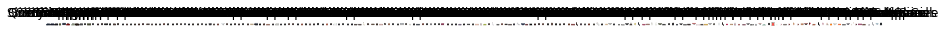

Accuracy of recommendation: 0.18


In [310]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Function to calculate similarity between two feature vectors
def recommend_image(query_image_features, all_image_features, top_k=5):
    similarity = cosine_similarity(query_image_features, all_image_features)
    indices = similarity.argsort()[0][-top_k:][::-1]  # Top K similar images
    return indices

# Function to display images with their actual classes and predicted accuracy
def show_recommended_images(query_image_idx, top_k_similar_indices, train, val, model, tokenizer, max_len=50):
    fig, axes = plt.subplots(1, len(top_k_similar_indices) + 1, figsize=(15, 5))
    
    # Load the query image from train set
    query_image = image.load_img(train['filename'][query_image_idx], target_size=(256, 256))
    axes[0].imshow(query_image)
    axes[0].set_title(f"Query Image")
    axes[0].axis('off')
    
    # Get the query image class
    query_image_label = train['masterCategory'].iloc[query_image_idx]
    
    # Show recommended images
    for i, idx in enumerate(top_k_similar_indices):
        # Load recommended image from val set
        recommended_image = image.load_img(val['filename'][idx], target_size=(256, 256))
        axes[i + 1].imshow(recommended_image)
        
        # Get the recommended image class (can be from val set)
        recommended_image_label = val['masterCategory'].iloc[idx]
        
        # Plot title showing the class label
        axes[i + 1].set_title(f"Sim {i+1}: {recommended_image_label}")
        
        axes[i + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy: is the class of any recommended image the same as the query image
    correct = sum(1 for idx in top_k_similar_indices if val['masterCategory'].iloc[idx] == query_image_label)
    accuracy = correct / len(top_k_similar_indices)
    print(f"Accuracy of recommendation: {accuracy:.2f}")

# Example: Recommending top 5 similar images from the validation set for the first image in the train set
query_image_idx = 0  # Change this index to query any image from the train set
query_image_features = train_features_combined[query_image_idx].reshape(1, -1)

# Get top 5 similar images from the validation set
top_5_similar_images = recommend_image(query_image_features, val_features_combined, top_k=200)

# Show the recommended images and their accuracy
show_recommended_images(query_image_idx, top_5_similar_images, train, val, model, tokenizer)


# Dimensionality Reduction
- The features extracted using the VGG16 Network product a vector of 512 features. So if we have lets say 10000 products the matrix of our data will be of the dimension 10000 x 512
- Lets see if we can reduce the dimension of this matrix
- For a linear projection based dimensionality reduction method to work there should be high correlation amongst the features
- But to visualize a correlation coeff table of such a high dimensional matrix will be highly resource utilizing
- Lets perform the PCA and see the variance explaination of the principal components to check if our linear projection approach works

In [311]:
train_features = train_features_combined
val_features = val_features_combined

In [312]:
from sklearn.decomposition import PCA

## Illustration of how PCA finds the axes where the within data variability will be maximum
- Lets proceed with 2 principal components first so that we can visualize them in 2D
- We will then look at the Cumulative Variance Explanation to find the right amount of principal components

<img src="https://miro.medium.com/max/1400/1*37a_i1t1tDxDYT3ZI6Yn8w.gif">

In [313]:
pca = PCA(2)
pca.fit(train_features)
train_pca = pca.transform(train_features)

In [314]:
test_pca = pca.fit_transform(val_features)

In [315]:
train_pca = pd.DataFrame(train_pca)
train = train.iloc[:,0:10]
train = train.merge(train_pca, how='left', left_index=True, right_index=True)

# Visualization: Principal Components

In [316]:
fig = px.scatter(train, x=0, y=1, color="masterCategory", title='Main Category', height=600, labels={
                     "0": "Principal Component 1",
                     "1": "Principal Component 2"})
fig.show()

In [317]:
fig = px.scatter(train, x=0, y=1, color="subCategory", title='Sub Category', height=600, labels={
                     "0": "Principal Component 1",
                     "1": "Principal Component 2"})
fig.show()

**Inference:**
- The 2 principal components show a reasonably good separability in terms of main product categories
- Maybe after taking more principal components the seprability will be more evident

In [318]:
pca = PCA()
pca.fit(train_features)
train_pca = pca.transform(train_features)
variance_explained = np.cumsum(pca.explained_variance_ratio_)
pcs = range(1,len(variance_explained)+1)

# Reduced Dimensions: 512 -> 313
- First 313 Principal Components explain 99% of the variance in data
- We will reduce the image feature dimensions to 313

In [319]:
px.line(x = pcs, y = variance_explained, title = 'Principal Components Cumulative Explained Variance', height=600,  labels={
                     "x": "Principal Components",
                     "y": "Explained Variance"})

In [320]:
val_pca = pca.fit_transform(val_features)[:,:313]
val_pca = pd.DataFrame(val_pca)
val = val.iloc[:,0:10]
val = val.merge(val_pca, how='left', left_index=True, right_index=True)

In [321]:
X = val.iloc[:,-313:]
y = val['id']

# K-Nearest Neighbours
- Lets use k=6, to recommend 6 most similar looking products
- We choose 6 because the first product out of the 6 similar looking products will be the query product itself
- Therefore we can now look at the 5 most similar products based on raw extracted features from the pre-trained network
- We will not use the predict method for classification prediction, but the KNeighbours method to find the k or 6 most nearest neighbours which have visually similar content
- The evaluation of such recommendation techniques is usually done using something like hit-rate, which is an indicator of if the user bought the product recommended to them

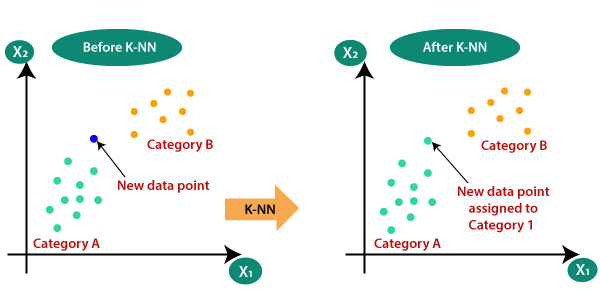

In [322]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X, y)

KNeighborsClassifier(n_neighbors=6)

In [323]:
def read_img(image_path):
    image = load_img(image_path,target_size=(256,256,3))
    image = img_to_array(image)
    image = image/255.
    return image

# Results
- The results can definitely improved by creating data of similar styled or branded products 
- A siamese network can then be trained to create image features where similarly styled or branded products are in closer proximity

In [324]:
import random

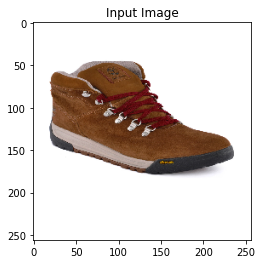

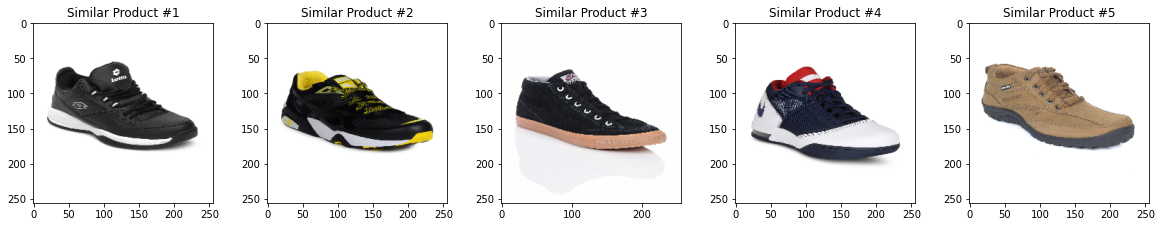

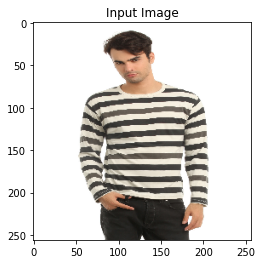

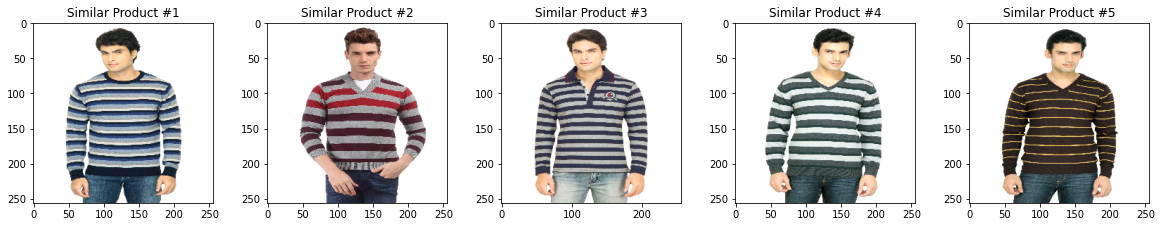

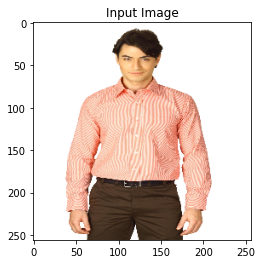

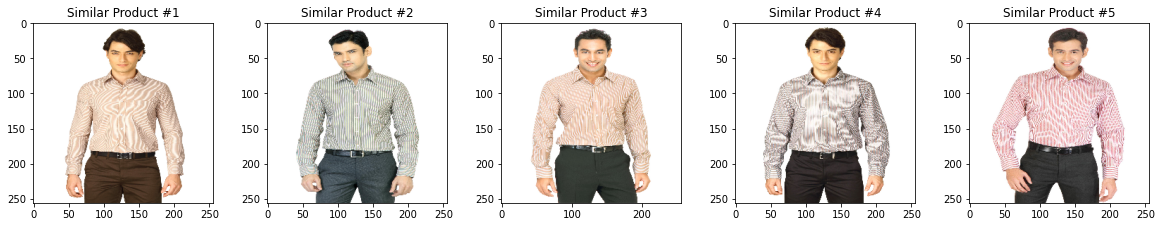

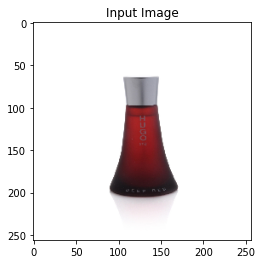

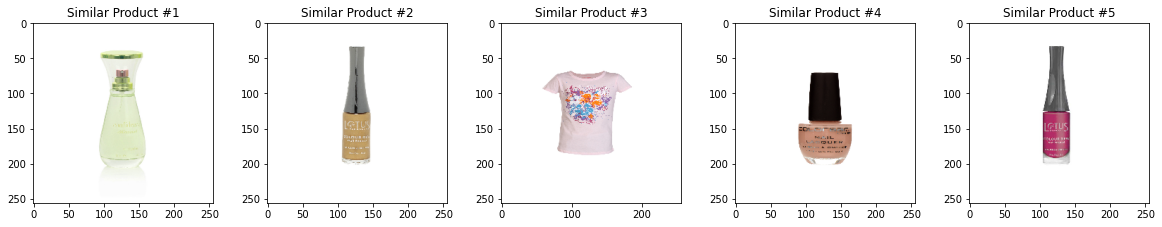

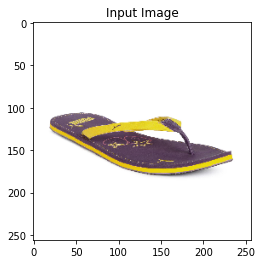

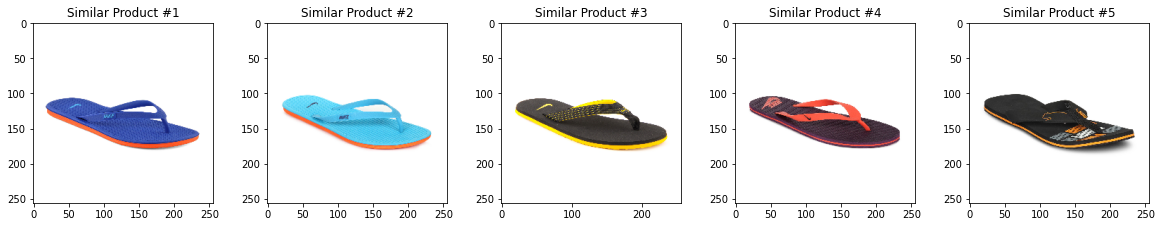

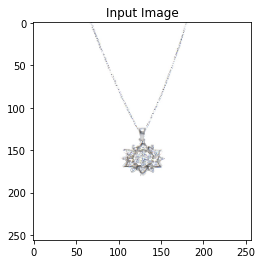

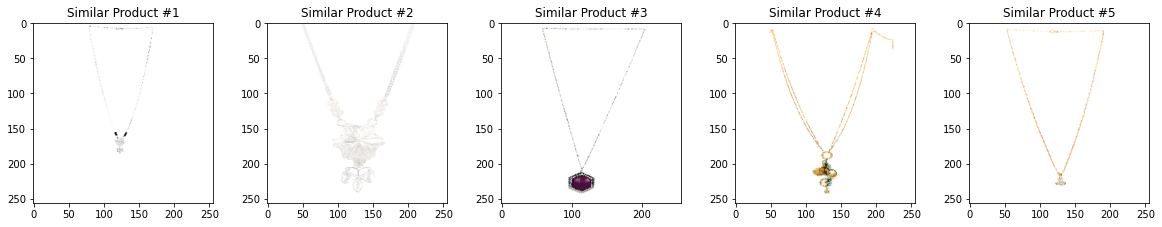

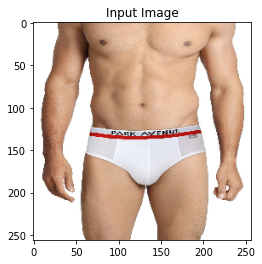

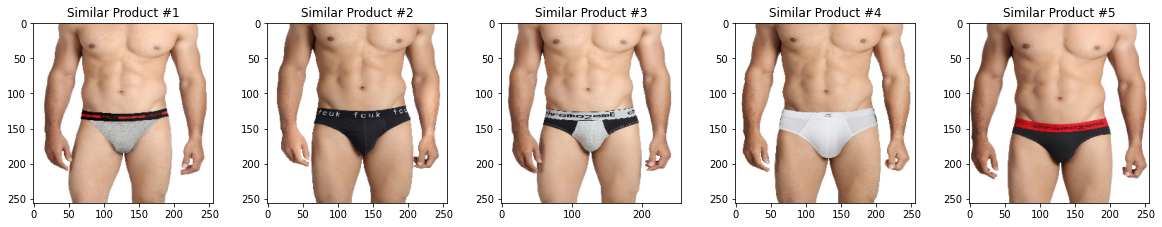

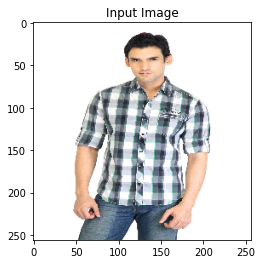

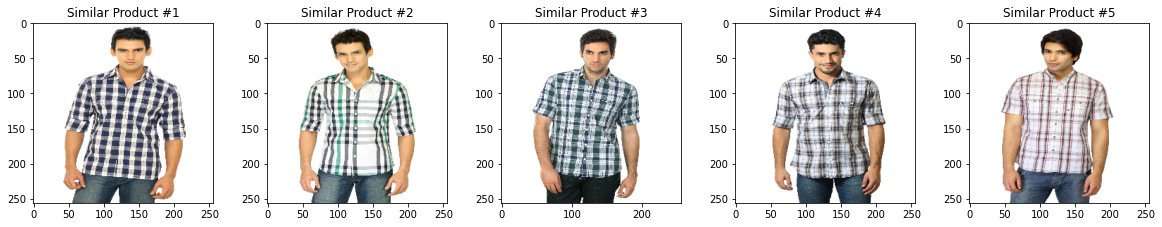

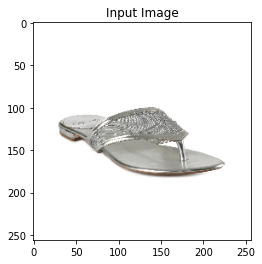

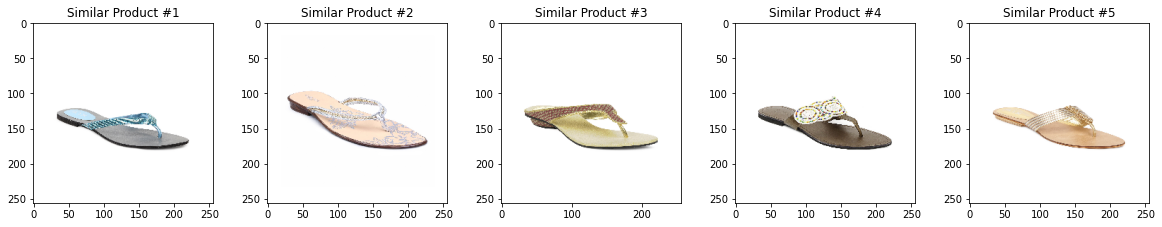

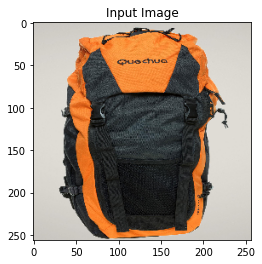

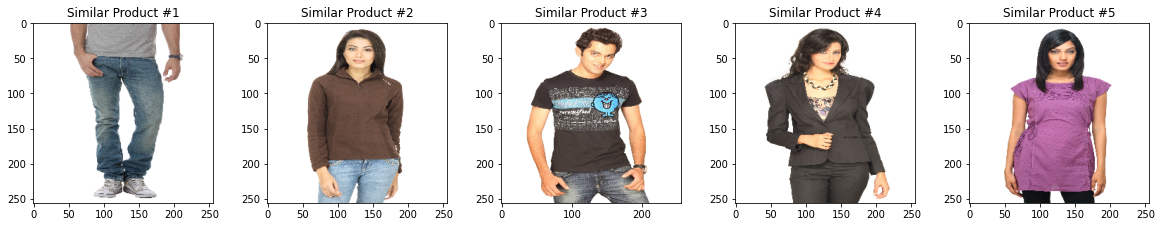

In [325]:
for _ in range(10):
    i = random.randint(1,len(val))
    img1 = read_img(val.loc[i,'filename'])
    dist, index = neigh.kneighbors(X=X.iloc[i,:].values.reshape(1,-1))
    plt.figure(figsize = (4 , 4))
    plt.imshow(img1)
    plt.title("Input Image")

    plt.figure(figsize = (20 , 20))
    for i in range(1,6):
        plt.subplot(1 , 5, i)
        plt.subplots_adjust(hspace = 0.5 , wspace = 0.3)
        image = read_img(val.loc[index[0][i],'filename'])
        plt.imshow(image)
        plt.title(f'Similar Product #{i}')

In [326]:
import random
from sklearn.metrics import accuracy_score

# Assuming you have a validation set `val` with a 'masterCategory' column
# Initialize a list to store the accuracy of recommendations
correct_recommendations = []

# Number of samples to evaluate
num_samples = 100 
num_neighbors = 50  # Number of recommendations

for _ in range(num_samples):
    i = random.randint(0, len(val) - 1)  # Random index
    true_category = val.loc[i, 'masterCategory']  # Actual master category of the input image
    _, indices = neigh.kneighbors(X=X.iloc[i, :].values.reshape(1, -1), n_neighbors=num_neighbors + 1)  # Get neighbors (including the image itself)
    
    # Get recommended categories (excluding the first index which is the input image itself)
    recommended_categories = val.loc[indices[0][1:], 'masterCategory'].values
    
    # Count correct recommendations
    correct = sum(recommended_categories == true_category)
    
    # Store the count of correct recommendations for this sample
    correct_recommendations.append(correct)

# Calculate the accuracy as the ratio of correct recommendations to total recommendations
total_correct = sum(correct_recommendations)
total_recommendations = num_samples * num_neighbors  # Total recommendations made

accuracy = total_correct / total_recommendations

print(f"Accuracy of product recommendations: {accuracy:.2%}")


Accuracy of product recommendations: 94.62%


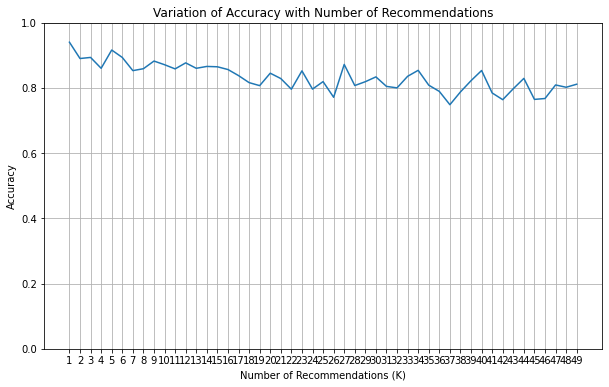

In [327]:
import random
import matplotlib.pyplot as plt

# Assuming you have a validation set `val` with a 'subCategory' column
# Initialize lists to store the number of recommendations and their corresponding accuracies
num_recommendations_list = []
accuracies = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 20 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations = []  # Reset for each number of neighbors
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        _, indices = neigh.kneighbors(X=X.iloc[i, :].values.reshape(1, -1), n_neighbors=num_neighbors + 1)  # Get neighbors
        
        # Get recommended categories (excluding the first index which is the input image itself)
        recommended_categories = val.loc[indices[0][1:], 'subCategory'].values
        
        # Count correct recommendations
        correct = sum(recommended_categories == true_category)
        
        # Store the count of correct recommendations for this sample
        correct_recommendations.append(correct)

    # Calculate the accuracy for this number of neighbors
    total_correct = sum(correct_recommendations)
    total_recommendations = num_samples * num_neighbors  # Total recommendations made
    accuracy = total_correct / total_recommendations
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies.append(accuracy)

# Plotting the accuracy variation with the number of recommendations
plt.figure(figsize=(10, 6))
plt.plot(num_recommendations_list, accuracies)
plt.title('Variation of Accuracy with Number of Recommendations')
plt.xlabel('Number of Recommendations (K)')
plt.ylabel('Accuracy')
plt.xticks(num_recommendations_list)
plt.grid()
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.show()

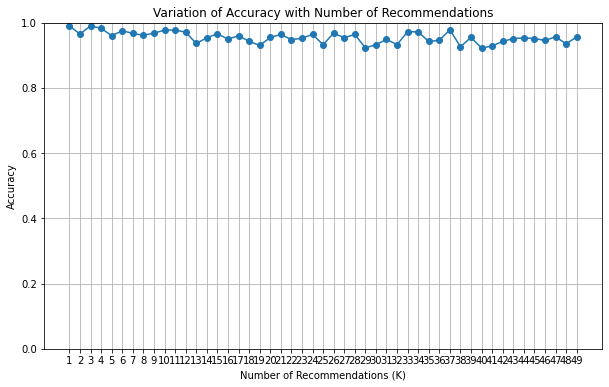

In [328]:
import random
import matplotlib.pyplot as plt

# Assuming you have a validation set `val` with a 'masterCategory' column
# Initialize lists to store the number of recommendations and their corresponding accuracies
num_recommendations_list = []
accuracies = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 20 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations = []  # Reset for each number of neighbors
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index
        true_category = val.loc[i, 'masterCategory']  # Actual master category of the input image
        _, indices = neigh.kneighbors(X=X.iloc[i, :].values.reshape(1, -1), n_neighbors=num_neighbors + 1)  # Get neighbors
        
        # Get recommended categories (excluding the first index which is the input image itself)
        recommended_categories = val.loc[indices[0][1:], 'masterCategory'].values
        
        # Count correct recommendations
        correct = sum(recommended_categories == true_category)
        
        # Store the count of correct recommendations for this sample
        correct_recommendations.append(correct)

    # Calculate the accuracy for this number of neighbors
    total_correct = sum(correct_recommendations)
    total_recommendations = num_samples * num_neighbors  # Total recommendations made
    accuracy = total_correct / total_recommendations
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies.append(accuracy)

# Plotting the accuracy variation with the number of recommendations
plt.figure(figsize=(10, 6))
plt.plot(num_recommendations_list, accuracies, marker='o')
plt.title('Variation of Accuracy with Number of Recommendations')
plt.xlabel('Number of Recommendations (K)')
plt.ylabel('Accuracy')
plt.xticks(num_recommendations_list)
plt.grid()
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.show()


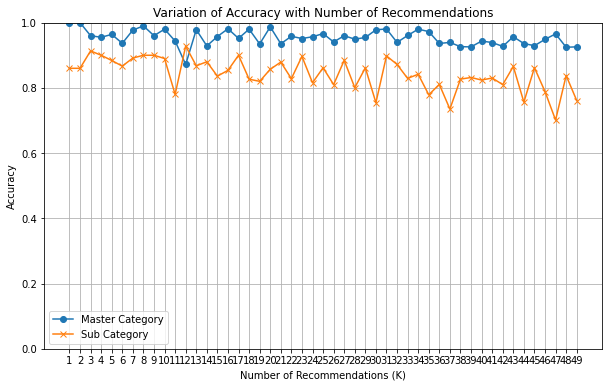

In [329]:
import random
import matplotlib.pyplot as plt

# Initialize lists to store the number of recommendations and their corresponding accuracies for both categories
num_recommendations_list = []
accuracies_masterCategory = []
accuracies_subCategory = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 20 recommendations

# Number of samples to evaluate
num_samples = 50

for num_neighbors in neighbor_values:
    # Append the current number of neighbors to the list
    num_recommendations_list.append(num_neighbors)

    # For masterCategory
    correct_recommendations_master = []  # Reset for each number of neighbors for masterCategory
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index
        true_category_master = val.loc[i, 'masterCategory']  # Actual master category of the input image
        _, indices = neigh.kneighbors(X=X.iloc[i, :].values.reshape(1, -1), n_neighbors=num_neighbors + 1)  # Get neighbors
        
        # Get recommended categories (excluding the first index which is the input image itself)
        recommended_categories_master = val.loc[indices[0][1:], 'masterCategory'].values
        
        # Count correct recommendations for masterCategory
        correct_master = sum(recommended_categories_master == true_category_master)
        correct_recommendations_master.append(correct_master)

    # Calculate the accuracy for masterCategory
    total_correct_master = sum(correct_recommendations_master)
    total_recommendations_master = num_samples * num_neighbors  # Total recommendations made
    accuracy_master = total_correct_master / total_recommendations_master
    accuracies_masterCategory.append(accuracy_master)

    # For subCategory
    correct_recommendations_sub = []  # Reset for each number of neighbors for subCategory
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index
        true_category_sub = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        _, indices = neigh.kneighbors(X=X.iloc[i, :].values.reshape(1, -1), n_neighbors=num_neighbors + 1)  # Get neighbors
        
        # Get recommended categories (excluding the first index which is the input image itself)
        recommended_categories_sub = val.loc[indices[0][1:], 'subCategory'].values
        
        # Count correct recommendations for subCategory
        correct_sub = sum(recommended_categories_sub == true_category_sub)
        correct_recommendations_sub.append(correct_sub)

    # Calculate the accuracy for subCategory
    total_correct_sub = sum(correct_recommendations_sub)
    total_recommendations_sub = num_samples * num_neighbors  # Total recommendations made
    accuracy_sub = total_correct_sub / total_recommendations_sub
    accuracies_subCategory.append(accuracy_sub)

# Plotting the accuracy variation with the number of recommendations for both categories
plt.figure(figsize=(10, 6))
plt.plot(num_recommendations_list, accuracies_masterCategory, marker='o', label='Master Category')
plt.plot(num_recommendations_list, accuracies_subCategory, marker='x', label='Sub Category')
plt.title('Variation of Accuracy with Number of Recommendations')
plt.xlabel('Number of Recommendations (K)')
plt.ylabel('Accuracy')
plt.xticks(num_recommendations_list)  # Set x-ticks to the number of recommendations tested
plt.grid()
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.legend()  # Show legend to differentiate categories
plt.show()


In [330]:
# import numpy as np
# import random
# import matplotlib.pyplot as plt
# from sklearn.metrics.pairwise import cosine_similarity

# # Initialize lists to store the number of recommendations and their corresponding accuracies
# num_recommendations_list = []
# accuracies = []

# # Define the range of recommendations to test
# recommendation_values = range(1, 51)  # Testing from 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# for num_recommendations in recommendation_values:
#     correct_recommendations = []  # Reset for each number of recommendations
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Calculate cosine similarity between the input image and all images in the dataset
#         similarities = cosine_similarity(X.iloc[i, :].values.reshape(1, -1), X)
        
#         # Get indices of the most similar items, excluding the input image itself
#         similar_indices = similarities.argsort()[0][-num_recommendations-1:-1][::-1]
        
#         # Get recommended categories based on the most similar items
#         recommended_categories = val.loc[similar_indices, 'subCategory'].values
        
#         # Count correct recommendations (i.e., if the true category matches any of the recommendations)
#         correct = sum(recommended_categories == true_category)
        
#         # Store the count of correct recommendations for this sample
#         correct_recommendations.append(correct)

#     # Calculate the accuracy for this number of recommendations
#     total_correct = sum(correct_recommendations)
#     total_recommendations = num_samples * num_recommendations  # Total recommendations made
#     accuracy = total_correct / total_recommendations
    
#     # Store the results
#     num_recommendations_list.append(num_recommendations)
#     accuracies.append(accuracy)

# # Plotting the accuracy variation with the number of recommendations
# plt.figure(figsize=(10, 6))
# plt.plot(num_recommendations_list, accuracies)
# plt.title('Variation of Accuracy with Number of Recommendations (Cosine Similarity)')
# plt.xlabel('Number of Recommendations')
# plt.ylabel('Accuracy')
# plt.xticks(num_recommendations_list)
# plt.grid()
# plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
# plt.show()


# UMAP + Cosine

In [331]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.metrics.pairwise import cosine_similarity
# import matplotlib.pyplot as plt

# # Assuming 'X' is the combined feature matrix and 'val' is the validation set
# # X is the combined image + text feature matrix (shape: num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and reduce the dimensionality of the features
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# # Initialize lists to store the number of recommendations and their corresponding accuracies
# num_recommendations_list = []
# accuracies = []

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# for num_neighbors in neighbor_values:
#     correct_recommendations = []  # Reset for each number of neighbors
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP space
#         query_point = X_umap[i, :].reshape(1, -1)
        
#         # Calculate cosine similarity between the query point and all other points in the UMAP space
#         cosine_similarities = cosine_similarity(query_point, X_umap)[0]
        
#         # Get the indices of the most similar points based on cosine similarity
#         similar_indices = np.argsort(cosine_similarities)[::-1][:num_neighbors + 1]  # Skip the first index (itself)
        
#         # Get recommended categories (excluding the first index which is the input image itself)
#         recommended_categories = val.loc[similar_indices[1:], 'subCategory'].values
        
#         # Count correct recommendations (if the true category matches any of the recommended categories)
#         correct = sum(recommended_categories == true_category)
        
#         # Store the count of correct recommendations for this sample
#         correct_recommendations.append(correct)

#     # Calculate the accuracy for this number of neighbors
#     total_correct = sum(correct_recommendations)
#     total_recommendations = num_samples * num_neighbors  # Total recommendations made
#     accuracy = total_correct / total_recommendations
    
#     # Store the results
#     num_recommendations_list.append(num_neighbors)
#     accuracies.append(accuracy)

# # Plotting the accuracy variation with the number of recommendations
# plt.figure(figsize=(10, 6))
# plt.plot(num_recommendations_list, accuracies)
# plt.title('Variation of Accuracy with Number of Recommendations (UMAP + Cosine Similarity)')
# plt.xlabel('Number of Recommendations (K)')
# plt.ylabel('Accuracy')
# plt.xticks(num_recommendations_list)
# plt.grid()
# plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
# plt.show()


In [332]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.neighbors import NearestNeighbors
# import matplotlib.pyplot as plt

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined feature matrix (num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and reduce the dimensionality of the features
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# # Initialize KNN model
# knn_model = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
# knn_model.fit(X_umap)

# # Initialize lists to store the number of recommendations and their corresponding accuracies
# num_recommendations_list = []
# accuracies = []

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# for num_neighbors in neighbor_values:
#     correct_recommendations = []  # Reset for each number of neighbors
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP space
#         query_point = X_umap[i, :].reshape(1, -1)
        
#         # Get the indices of the most similar neighbors based on KNN
#         _, indices = knn_model.kneighbors(query_point, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
        
#         # Get recommended categories (excluding the first index which is the input image itself)
#         recommended_categories = val.loc[indices[0][1:], 'subCategory'].values
        
#         # Count correct recommendations (if the true category matches any of the recommended categories)
#         correct = sum(recommended_categories == true_category)
        
#         # Store the count of correct recommendations for this sample
#         correct_recommendations.append(correct)

#     # Calculate the accuracy for this number of neighbors
#     total_correct = sum(correct_recommendations)
#     total_recommendations = num_samples * num_neighbors  # Total recommendations made
#     accuracy = total_correct / total_recommendations
    
#     # Store the results
#     num_recommendations_list.append(num_neighbors)
#     accuracies.append(accuracy)

# # Plotting the accuracy variation with the number of recommendations
# plt.figure(figsize=(10, 6))
# plt.plot(num_recommendations_list, accuracies)
# plt.title('Variation of Accuracy with Number of Recommendations (UMAP + KNN)')
# plt.xlabel('Number of Recommendations (K)')
# plt.ylabel('Accuracy')
# plt.xticks(num_recommendations_list)
# plt.grid()
# plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
# plt.show()


In [333]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.neighbors import NearestNeighbors
# from sklearn.metrics import precision_score, recall_score, accuracy_score
# import matplotlib.pyplot as plt
# from sklearn.metrics import precision_recall_curve

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined feature matrix (num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # train_features = train_features_combined
# # val_features = val_features_combined
# # X=train_features
# # val=val_features
# # Initialize UMAP and reduce the dimensionality of the features
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# # Initialize KNN model
# knn_model = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
# knn_model.fit(X_umap)

# # Initialize lists to store metrics for both methods
# metrics = {
#     'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': []},
#     'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': []}
# }

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# # UMAP + Cosine Similarity and UMAP + KNN combined evaluation
# for num_neighbors in neighbor_values:
#     correct_recommendations_cosine = []  # Reset for each number of neighbors
#     correct_recommendations_knn = []  # Reset for each number of neighbors
    
#     true_categories_cosine = []  # List to store true categories for cosine
#     true_categories_knn = []  # List to store true categories for KNN
    
#     recommended_categories_cosine = []  # List to store recommended categories for cosine
#     recommended_categories_knn = []  # List to store recommended categories for KNN
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP space
#         query_point = X_umap[i, :].reshape(1, -1)
        
#         # UMAP + Cosine Similarity
#         cosine_distances = np.dot(X_umap, query_point.T).flatten()  # Cosine similarity
#         cosine_indices = np.argsort(cosine_distances)[-num_neighbors - 1: -1]  # Get top K neighbors
        
#         recommended_categories_cosine_batch = val.loc[cosine_indices, 'subCategory'].values
#         recommended_categories_cosine.append(recommended_categories_cosine_batch)
        
#         # UMAP + KNN
#         _, knn_indices = knn_model.kneighbors(query_point, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
#         recommended_categories_knn_batch = val.loc[knn_indices[0][1:], 'subCategory'].values
#         recommended_categories_knn.append(recommended_categories_knn_batch)

#         true_categories_cosine.append(true_category)
#         true_categories_knn.append(true_category)
        
#     # Calculate accuracy, precision, and recall for UMAP + Cosine
#     accuracy_cosine = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_cosine, true_categories_cosine)]) / num_samples
#     precision_cosine = precision_score(true_categories_cosine, [rec[0] for rec in recommended_categories_cosine], average='micro')
#     recall_cosine = recall_score(true_categories_cosine, [rec[0] for rec in recommended_categories_cosine], average='micro')
    
#     # Calculate accuracy, precision, and recall for UMAP + KNN
#     accuracy_knn = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_knn, true_categories_knn)]) / num_samples
#     precision_knn = precision_score(true_categories_knn, [rec[0] for rec in recommended_categories_knn], average='micro')
#     recall_knn = recall_score(true_categories_knn, [rec[0] for rec in recommended_categories_knn], average='micro')
    
#     # Store the results
#     metrics['UMAP + Cosine']['accuracy'].append(accuracy_cosine)
#     metrics['UMAP + Cosine']['precision'].append(precision_cosine)
#     metrics['UMAP + Cosine']['recall'].append(recall_cosine)
    
#     metrics['UMAP + KNN']['accuracy'].append(accuracy_knn)
#     metrics['UMAP + KNN']['precision'].append(precision_knn)
#     metrics['UMAP + KNN']['recall'].append(recall_knn)

# # Plotting the metrics
# fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# # Accuracy plot
# axs[0].plot(neighbor_values, metrics['UMAP + Cosine']['accuracy'], label='UMAP + Cosine', color='blue')
# axs[0].plot(neighbor_values, metrics['UMAP + KNN']['accuracy'], label='UMAP + KNN', color='green')
# axs[0].set_title('Accuracy vs Number of Recommendations')
# axs[0].set_xlabel('Number of Recommendations (K)')
# axs[0].set_ylabel('Accuracy')
# axs[0].legend()
# axs[0].grid()

# # Precision plot
# axs[1].plot(neighbor_values, metrics['UMAP + Cosine']['precision'], label='UMAP + Cosine', color='blue')
# axs[1].plot(neighbor_values, metrics['UMAP + KNN']['precision'], label='UMAP + KNN', color='green')
# axs[1].set_title('Precision vs Number of Recommendations')
# axs[1].set_xlabel('Number of Recommendations (K)')
# axs[1].set_ylabel('Precision')
# axs[1].legend()
# axs[1].grid()

# # Recall plot
# axs[2].plot(neighbor_values, metrics['UMAP + Cosine']['recall'], label='UMAP + Cosine', color='blue')
# axs[2].plot(neighbor_values, metrics['UMAP + KNN']['recall'], label='UMAP + KNN', color='green')
# axs[2].set_title('Recall vs Number of Recommendations')
# axs[2].set_xlabel('Number of Recommendations (K)')
# axs[2].set_ylabel('Recall')
# axs[2].legend()
# axs[2].grid()

# plt.tight_layout()
# plt.show()


In [334]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.neighbors import NearestNeighbors
# from sklearn.metrics import precision_score, recall_score, accuracy_score
# import matplotlib.pyplot as plt
# import time  # For time measurement

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined feature matrix (num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and PCA models for dimensionality reduction
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# pca_model = PCA(n_components=50)  # Using 50 components for PCA

# # Apply UMAP and PCA to the features
# X_umap = umap_model.fit_transform(X)  # UMAP reduced features
# X_pca = pca_model.fit_transform(X)  # PCA reduced features

# # Initialize KNN model
# knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')  # KNN on UMAP
# knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')  # KNN on PCA

# # Fit KNN on both UMAP and PCA reduced data
# knn_model_umap.fit(X_umap)
# knn_model_pca.fit(X_pca)

# # Initialize lists to store metrics for both methods
# metrics = {
#     'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []}
# }

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# # Evaluation for all four models (UMAP + Cosine, UMAP + KNN, PCA + Cosine, PCA + KNN)
# for num_neighbors in neighbor_values:
#     correct_recommendations_cosine_umap = []  # Reset for UMAP + Cosine
#     correct_recommendations_knn_umap = []  # Reset for UMAP + KNN
#     correct_recommendations_cosine_pca = []  # Reset for PCA + Cosine
#     correct_recommendations_knn_pca = []  # Reset for PCA + KNN
    
#     true_categories_cosine_umap = []  # True categories for UMAP + Cosine
#     true_categories_knn_umap = []  # True categories for UMAP + KNN
#     true_categories_cosine_pca = []  # True categories for PCA + Cosine
#     true_categories_knn_pca = []  # True categories for PCA + KNN
    
#     recommended_categories_cosine_umap = []  # Recommended categories for UMAP + Cosine
#     recommended_categories_knn_umap = []  # Recommended categories for UMAP + KNN
#     recommended_categories_cosine_pca = []  # Recommended categories for PCA + Cosine
#     recommended_categories_knn_pca = []  # Recommended categories for PCA + KNN
    
#     time_cosine_umap = []  # Time taken for UMAP + Cosine
#     time_knn_umap = []  # Time taken for UMAP + KNN
#     time_cosine_pca = []  # Time taken for PCA + Cosine
#     time_knn_pca = []  # Time taken for PCA + KNN
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP and PCA space
#         query_point_umap = X_umap[i, :].reshape(1, -1)
#         query_point_pca = X_pca[i, :].reshape(1, -1)
        
#         # UMAP + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_umap = np.dot(X_umap, query_point_umap.T).flatten()  # Cosine similarity for UMAP
#         cosine_indices_umap = np.argsort(cosine_distances_umap)[-num_neighbors - 1: -1]  # Get top K neighbors
#         time_cosine_umap.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_cosine_umap_batch = val.loc[cosine_indices_umap, 'subCategory'].values
#         recommended_categories_cosine_umap.append(recommended_categories_cosine_umap_batch)
        
#         # PCA + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_pca = np.dot(X_pca, query_point_pca.T).flatten()  # Cosine similarity for PCA
#         cosine_indices_pca = np.argsort(cosine_distances_pca)[-num_neighbors - 1: -1]  # Get top K neighbors
#         time_cosine_pca.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_cosine_pca_batch = val.loc[cosine_indices_pca, 'subCategory'].values
#         recommended_categories_cosine_pca.append(recommended_categories_cosine_pca_batch)

#         # UMAP + KNN
#         start_time = time.time()
#         _, knn_indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
#         time_knn_umap.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_knn_umap_batch = val.loc[knn_indices_umap[0][1:], 'subCategory'].values
#         recommended_categories_knn_umap.append(recommended_categories_knn_umap_batch)

#         # PCA + KNN
#         start_time = time.time()
#         _, knn_indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
#         time_knn_pca.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_knn_pca_batch = val.loc[knn_indices_pca[0][1:], 'subCategory'].values
#         recommended_categories_knn_pca.append(recommended_categories_knn_pca_batch)

#         # Add the true categories for each model
#         true_categories_cosine_umap.append(true_category)
#         true_categories_knn_umap.append(true_category)
#         true_categories_cosine_pca.append(true_category)
#         true_categories_knn_pca.append(true_category)
        
#     # Calculate accuracy, precision, recall, and time for all models
#     accuracy_cosine_umap = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_cosine_umap, true_categories_cosine_umap)]) / num_samples
#     precision_cosine_umap = precision_score(true_categories_cosine_umap, [rec[0] for rec in recommended_categories_cosine_umap], average='micro')
#     recall_cosine_umap = recall_score(true_categories_cosine_umap, [rec[0] for rec in recommended_categories_cosine_umap], average='micro')
    
#     accuracy_knn_umap = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_knn_umap, true_categories_knn_umap)]) / num_samples
#     precision_knn_umap = precision_score(true_categories_knn_umap, [rec[0] for rec in recommended_categories_knn_umap], average='micro')
#     recall_knn_umap = recall_score(true_categories_knn_umap, [rec[0] for rec in recommended_categories_knn_umap], average='micro')
    
#     accuracy_cosine_pca = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_cosine_pca, true_categories_cosine_pca)]) / num_samples
#     precision_cosine_pca = precision_score(true_categories_cosine_pca, [rec[0] for rec in recommended_categories_cosine_pca], average='micro')
#     recall_cosine_pca = recall_score(true_categories_cosine_pca, [rec[0] for rec in recommended_categories_cosine_pca], average='micro')
    
#     accuracy_knn_pca = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories_knn_pca, true_categories_knn_pca)]) / num_samples
#     precision_knn_pca = precision_score(true_categories_knn_pca, [rec[0] for rec in recommended_categories_knn_pca], average='micro')
#     recall_knn_pca = recall_score(true_categories_knn_pca, [rec[0] for rec in recommended_categories_knn_pca], average='micro')

#     # Append results to metrics dictionary
#     metrics['UMAP + Cosine']['accuracy'].append(accuracy_cosine_umap)
#     metrics['UMAP + Cosine']['precision'].append(precision_cosine_umap)
#     metrics['UMAP + Cosine']['recall'].append(recall_cosine_umap)
#     metrics['UMAP + Cosine']['time'].append(np.mean(time_cosine_umap))

#     metrics['UMAP + KNN']['accuracy'].append(accuracy_knn_umap)
#     metrics['UMAP + KNN']['precision'].append(precision_knn_umap)
#     metrics['UMAP + KNN']['recall'].append(recall_knn_umap)
#     metrics['UMAP + KNN']['time'].append(np.mean(time_knn_umap))

#     metrics['PCA + Cosine']['accuracy'].append(accuracy_cosine_pca)
#     metrics['PCA + Cosine']['precision'].append(precision_cosine_pca)
#     metrics['PCA + Cosine']['recall'].append(recall_cosine_pca)
#     metrics['PCA + Cosine']['time'].append(np.mean(time_cosine_pca))

#     metrics['PCA + KNN']['accuracy'].append(accuracy_knn_pca)
#     metrics['PCA + KNN']['precision'].append(precision_knn_pca)
#     metrics['PCA + KNN']['recall'].append(recall_knn_pca)
#     metrics['PCA + KNN']['time'].append(np.mean(time_knn_pca))

# # Plotting accuracy, precision, recall, and time for all models
# fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# # Accuracy
# axes[0].plot(neighbor_values, metrics['UMAP + Cosine']['accuracy'], label='UMAP + Cosine')
# axes[0].plot(neighbor_values, metrics['UMAP + KNN']['accuracy'], label='UMAP + KNN')
# axes[0].plot(neighbor_values, metrics['PCA + Cosine']['accuracy'], label='PCA + Cosine')
# axes[0].plot(neighbor_values, metrics['PCA + KNN']['accuracy'], label='PCA + KNN')
# axes[0].set_title('Accuracy vs Neighbors')
# axes[0].set_xlabel('Number of Neighbors')
# axes[0].set_ylabel('Accuracy')
# axes[0].legend()

# # Precision
# axes[1].plot(neighbor_values, metrics['UMAP + Cosine']['precision'], label='UMAP + Cosine')
# axes[1].plot(neighbor_values, metrics['UMAP + KNN']['precision'], label='UMAP + KNN')
# axes[1].plot(neighbor_values, metrics['PCA + Cosine']['precision'], label='PCA + Cosine')
# axes[1].plot(neighbor_values, metrics['PCA + KNN']['precision'], label='PCA + KNN')
# axes[1].set_title('Precision vs Neighbors')
# axes[1].set_xlabel('Number of Neighbors')
# axes[1].set_ylabel('Precision')
# axes[1].legend()

# # Recall
# axes[2].plot(neighbor_values, metrics['UMAP + Cosine']['recall'], label='UMAP + Cosine')
# axes[2].plot(neighbor_values, metrics['UMAP + KNN']['recall'], label='UMAP + KNN')
# axes[2].plot(neighbor_values, metrics['PCA + Cosine']['recall'], label='PCA + Cosine')
# axes[2].plot(neighbor_values, metrics['PCA + KNN']['recall'], label='PCA + KNN')
# axes[2].set_title('Recall vs Neighbors')
# axes[2].set_xlabel('Number of Neighbors')
# axes[2].set_ylabel('Recall')
# axes[2].legend()

# # Time taken for recommendation
# axes[3].plot(neighbor_values, metrics['UMAP + Cosine']['time'], label='UMAP + Cosine')
# axes[3].plot(neighbor_values, metrics['UMAP + KNN']['time'], label='UMAP + KNN')
# axes[3].plot(neighbor_values, metrics['PCA + Cosine']['time'], label='PCA + Cosine')
# axes[3].plot(neighbor_values, metrics['PCA + KNN']['time'], label='PCA + KNN')
# axes[3].set_title('Time taken vs Neighbors')
# axes[3].set_xlabel('Number of Neighbors')
# axes[3].set_ylabel('Time (seconds)')
# axes[3].legend()

# plt.tight_layout()
# plt.show()


In [335]:
# import pandas as pd

# # Define the specific recommendation values you want to display
# selected_neighbors = [10, 20, 30, 40, 50]

# # Create a DataFrame to display the metrics as a table
# metrics_df = pd.DataFrame({
#     'Neighbors': list(neighbor_values),
#     'UMAP + Cosine Accuracy': metrics['UMAP + Cosine']['accuracy'],
#     'UMAP + Cosine Precision': metrics['UMAP + Cosine']['precision'],
#     'UMAP + Cosine Recall': metrics['UMAP + Cosine']['recall'],
#     'UMAP + Cosine Time (s)': metrics['UMAP + Cosine']['time'],
    
#     'UMAP + KNN Accuracy': metrics['UMAP + KNN']['accuracy'],
#     'UMAP + KNN Precision': metrics['UMAP + KNN']['precision'],
#     'UMAP + KNN Recall': metrics['UMAP + KNN']['recall'],
#     'UMAP + KNN Time (s)': metrics['UMAP + KNN']['time'],
    
#     'PCA + Cosine Accuracy': metrics['PCA + Cosine']['accuracy'],
#     'PCA + Cosine Precision': metrics['PCA + Cosine']['precision'],
#     'PCA + Cosine Recall': metrics['PCA + Cosine']['recall'],
#     'PCA + Cosine Time (s)': metrics['PCA + Cosine']['time'],
    
#     'PCA + KNN Accuracy': metrics['PCA + KNN']['accuracy'],
#     'PCA + KNN Precision': metrics['PCA + KNN']['precision'],
#     'PCA + KNN Recall': metrics['PCA + KNN']['recall'],
#     'PCA + KNN Time (s)': metrics['PCA + KNN']['time']
# })

# # Filter rows for the selected neighbors
# metrics_df_filtered = metrics_df[metrics_df['Neighbors'].isin(selected_neighbors)]

# # Display the filtered metrics DataFrame
# print(metrics_df_filtered)


In [336]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from annoy import AnnoyIndex
# import matplotlib.pyplot as plt

# # Assuming 'X' is the combined feature matrix and 'val' is the validation set
# # X is the combined image + text feature matrix (shape: num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and reduce the dimensionality of the features
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# # Initialize Annoy index for approximate nearest neighbors search
# f = X_umap.shape[1]  # Number of dimensions after UMAP reduction
# annoy_index = AnnoyIndex(f, 'angular')  # Using 'angular' distance (cosine similarity)

# # Build the Annoy index
# for i in range(len(X_umap)):
#     annoy_index.add_item(i, X_umap[i, :])

# # Build the index (can take some time depending on the number of samples)
# annoy_index.build(10)  # '10' is the number of trees, larger value = better approximation but slower

# # Initialize lists to store the number of recommendations and their corresponding accuracies
# num_recommendations_list = []
# accuracies = []

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# for num_neighbors in neighbor_values:
#     correct_recommendations = []  # Reset for each number of neighbors
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP space
#         query_point = X_umap[i, :].reshape(1, -1)
        
#         # Use Annoy to get the most similar indices based on angular distance
#         similar_indices = annoy_index.get_nns_by_vector(query_point[0], num_neighbors + 1, include_distances=False)  # Skip the first index (itself)
        
#         # Get recommended categories (excluding the first index which is the input image itself)
#         recommended_categories = val.loc[similar_indices[1:], 'subCategory'].values
        
#         # Count correct recommendations (if the true category matches any of the recommended categories)
#         correct = sum(recommended_categories == true_category)
        
#         # Store the count of correct recommendations for this sample
#         correct_recommendations.append(correct)

#     # Calculate the accuracy for this number of neighbors
#     total_correct = sum(correct_recommendations)
#     total_recommendations = num_samples * num_neighbors  # Total recommendations made
#     accuracy = total_correct / total_recommendations
    
#     # Store the results
#     num_recommendations_list.append(num_neighbors)
#     accuracies.append(accuracy)

# # Plotting the accuracy variation with the number of recommendations
# plt.figure(figsize=(10, 6))
# plt.plot(num_recommendations_list, accuracies)
# plt.title('Variation of Accuracy with Number of Recommendations (UMAP + Annoy)')
# plt.xlabel('Number of Recommendations (K)')
# plt.ylabel('Accuracy')
# plt.xticks(num_recommendations_list)
# plt.grid()
# plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
# plt.show()


In [337]:
# import random
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from annoy import AnnoyIndex
# import matplotlib.pyplot as plt

# # Assuming 'X' is the combined feature matrix and 'val' is the validation set
# # X is the combined image + text feature matrix (shape: num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize PCA and reduce the dimensionality of the features
# pca_model = PCA(n_components=50)  # Set the number of components to keep
# X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# # Initialize Annoy index for approximate nearest neighbors search
# f = X_pca.shape[1]  # Number of dimensions after PCA reduction
# annoy_index = AnnoyIndex(f, 'angular')  # Using 'angular' distance (cosine similarity)

# # Build the Annoy index
# for i in range(len(X_pca)):
#     annoy_index.add_item(i, X_pca[i, :])

# # Build the index (can take some time depending on the number of samples)
# annoy_index.build(10)  # '10' is the number of trees, larger value = better approximation but slower

# # Initialize lists to store the number of recommendations and their corresponding accuracies
# num_recommendations_list = []
# accuracies = []

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# for num_neighbors in neighbor_values:
#     correct_recommendations = []  # Reset for each number of neighbors
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced PCA space
#         query_point = X_pca[i, :].reshape(1, -1)
        
#         # Use Annoy to get the most similar indices based on angular distance
#         similar_indices = annoy_index.get_nns_by_vector(query_point[0], num_neighbors + 1, include_distances=False)  # Skip the first index (itself)
        
#         # Get recommended categories (excluding the first index which is the input image itself)
#         recommended_categories = val.loc[similar_indices[1:], 'subCategory'].values
        
#         # Count correct recommendations (if the true category matches any of the recommended categories)
#         correct = sum(recommended_categories == true_category)
        
#         # Store the count of correct recommendations for this sample
#         correct_recommendations.append(correct)

#     # Calculate the accuracy for this number of neighbors
#     total_correct = sum(correct_recommendations)
#     total_recommendations = num_samples * num_neighbors  # Total recommendations made
#     accuracy = total_correct / total_recommendations
    
#     # Store the results
#     num_recommendations_list.append(num_neighbors)
#     accuracies.append(accuracy)

# # Plotting the accuracy variation with the number of recommendations
# plt.figure(figsize=(10, 6))
# plt.plot(num_recommendations_list, accuracies)
# plt.title('Variation of Accuracy with Number of Recommendations (PCA + Annoy)')
# plt.xlabel('Number of Recommendations (K)')
# plt.ylabel('Accuracy')
# plt.xticks(num_recommendations_list)
# plt.grid()
# plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
# plt.show()


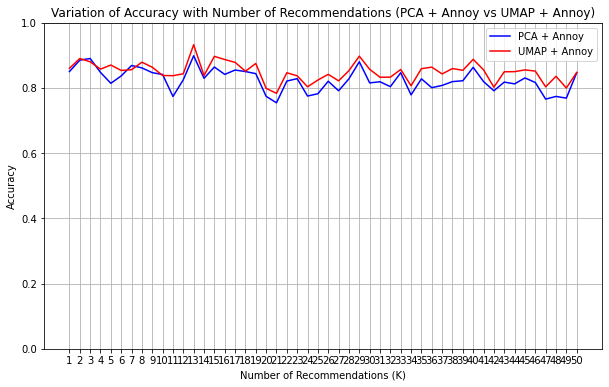

In [338]:
import random
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import umap
from annoy import AnnoyIndex
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'X' is the combined feature matrix and 'val' is the validation set
# X is the combined image + text feature matrix (shape: num_samples x num_features)
# 'subCategory' is the true category in the validation set

# Initialize UMAP and PCA models for dimensionality reduction
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
pca_model = PCA(n_components=50)

# Transform the features using UMAP and PCA
X_umap = umap_model.fit_transform(X)
X_pca = pca_model.fit_transform(X)

# Initialize Annoy index for PCA and UMAP
f = X_pca.shape[1]  # Number of dimensions after PCA and UMAP (both are 50)
annoy_index_pca = AnnoyIndex(f, 'angular')
annoy_index_umap = AnnoyIndex(f, 'angular')

# Build Annoy indexes for both PCA and UMAP transformed data
for i in range(len(X_pca)):
    annoy_index_pca.add_item(i, X_pca[i, :])
    annoy_index_umap.add_item(i, X_umap[i, :])

# Build the indexes (can take some time depending on the number of samples)
annoy_index_pca.build(10)
annoy_index_umap.build(10)

# Initialize lists to store the number of recommendations and their corresponding accuracies
num_recommendations_list = []
accuracies_pca = []
accuracies_umap = []

# Define the range of neighbors to test
neighbor_values = range(1, 51)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

# Loop over the number of neighbors to test for both PCA and UMAP
for num_neighbors in neighbor_values:
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    correct_recommendations_umap = []  # Reset for each number of neighbors for UMAP
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        query_point_umap = X_umap[i, :].reshape(1, -1)
        
        # Use Annoy to get the most similar indices based on angular distance
        similar_indices_pca = annoy_index_pca.get_nns_by_vector(query_point_pca[0], num_neighbors + 1, include_distances=False)  # Skip the first index (itself)
        similar_indices_umap = annoy_index_umap.get_nns_by_vector(query_point_umap[0], num_neighbors + 1, include_distances=False)  # Skip the first index (itself)
        
        # Get recommended categories (excluding the first index which is the input image itself)
        recommended_categories_pca = val.loc[similar_indices_pca[1:], 'subCategory'].values
        recommended_categories_umap = val.loc[similar_indices_umap[1:], 'subCategory'].values
        
        # Count correct recommendations (if the true category matches any of the recommended categories)
        correct_pca = sum(recommended_categories_pca == true_category)
        correct_umap = sum(recommended_categories_umap == true_category)
        
        # Store the count of correct recommendations for both PCA and UMAP
        correct_recommendations_pca.append(correct_pca)
        correct_recommendations_umap.append(correct_umap)

    # Calculate the accuracy for this number of neighbors for both PCA and UMAP
    total_correct_pca = sum(correct_recommendations_pca)
    total_correct_umap = sum(correct_recommendations_umap)
    total_recommendations = num_samples * num_neighbors  # Total recommendations made
    
    accuracy_pca = total_correct_pca / total_recommendations
    accuracy_umap = total_correct_umap / total_recommendations
    
    # Store the results for both PCA and UMAP
    accuracies_pca.append(accuracy_pca)
    accuracies_umap.append(accuracy_umap)
    num_recommendations_list.append(num_neighbors)

# Plotting the accuracy variation with the number of recommendations for both PCA + Annoy and UMAP + Annoy
plt.figure(figsize=(10, 6))
plt.plot(num_recommendations_list, accuracies_pca, label="PCA + Annoy", color='b')
plt.plot(num_recommendations_list, accuracies_umap, label="UMAP + Annoy", color='r')
plt.title('Variation of Accuracy with Number of Recommendations (PCA + Annoy vs UMAP + Annoy)')
plt.xlabel('Number of Recommendations (K)')
plt.ylabel('Accuracy')
plt.xticks(num_recommendations_list)
plt.grid()
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.legend()
plt.show()


In [339]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.neighbors import NearestNeighbors
# from sklearn.metrics import precision_score, recall_score, accuracy_score
# import matplotlib.pyplot as plt
# import time  # For time measurement
# from annoy import AnnoyIndex  # Import Annoy library

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined feature matrix (num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and PCA models for dimensionality reduction
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# pca_model = PCA(n_components=50)  # Using 50 components for PCA

# # Apply UMAP and PCA to the features
# X_umap = umap_model.fit_transform(X)  # UMAP reduced features
# X_pca = pca_model.fit_transform(X)  # PCA reduced features

# # Initialize KNN model
# knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')  # KNN on UMAP
# knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')  # KNN on PCA

# # Fit KNN on both UMAP and PCA reduced data
# knn_model_umap.fit(X_umap)
# knn_model_pca.fit(X_pca)

# # Create Annoy index for UMAP + Annoy and PCA + Annoy
# annoy_model_umap = AnnoyIndex(X_umap.shape[1], 'angular')  # Angular distance for UMAP Annoy
# annoy_model_pca = AnnoyIndex(X_pca.shape[1], 'angular')  # Angular distance for PCA Annoy

# # Add items to Annoy index
# for i in range(len(X_umap)):
#     annoy_model_umap.add_item(i, X_umap[i])  # Adding UMAP vectors to Annoy index
#     annoy_model_pca.add_item(i, X_pca[i])  # Adding PCA vectors to Annoy index

# # Build the Annoy index (this step may take some time)
# annoy_model_umap.build(10)  # Build with 10 trees for UMAP
# annoy_model_pca.build(10)  # Build with 10 trees for PCA

# # Initialize lists to store metrics for all models
# metrics = {
#     'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []}
# }

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# # Evaluation for all models (UMAP + Cosine, UMAP + KNN, PCA + Cosine, PCA + KNN, UMAP + Annoy, PCA + Annoy)
# for num_neighbors in neighbor_values:
#     correct_recommendations_cosine_umap = []  # Reset for UMAP + Cosine
#     correct_recommendations_knn_umap = []  # Reset for UMAP + KNN
#     correct_recommendations_cosine_pca = []  # Reset for PCA + Cosine
#     correct_recommendations_knn_pca = []  # Reset for PCA + KNN
#     correct_recommendations_annoy_umap = []  # Reset for UMAP + Annoy
#     correct_recommendations_annoy_pca = []  # Reset for PCA + Annoy
    
#     true_categories_cosine_umap = []  # True categories for UMAP + Cosine
#     true_categories_knn_umap = []  # True categories for UMAP + KNN
#     true_categories_cosine_pca = []  # True categories for PCA + Cosine
#     true_categories_knn_pca = []  # True categories for PCA + KNN
#     true_categories_annoy_umap = []  # True categories for UMAP + Annoy
#     true_categories_annoy_pca = []  # True categories for PCA + Annoy
    
#     recommended_categories_cosine_umap = []  # Recommended categories for UMAP + Cosine
#     recommended_categories_knn_umap = []  # Recommended categories for UMAP + KNN
#     recommended_categories_cosine_pca = []  # Recommended categories for PCA + Cosine
#     recommended_categories_knn_pca = []  # Recommended categories for PCA + KNN
#     recommended_categories_annoy_umap = []  # Recommended categories for UMAP + Annoy
#     recommended_categories_annoy_pca = []  # Recommended categories for PCA + Annoy
    
#     time_cosine_umap = []  # Time taken for UMAP + Cosine
#     time_knn_umap = []  # Time taken for UMAP + KNN
#     time_cosine_pca = []  # Time taken for PCA + Cosine
#     time_knn_pca = []  # Time taken for PCA + KNN
#     time_annoy_umap = []  # Time taken for UMAP + Annoy
#     time_annoy_pca = []  # Time taken for PCA + Annoy
    
#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced UMAP and PCA space
#         query_point_umap = X_umap[i, :].reshape(1, -1)
#         query_point_pca = X_pca[i, :].reshape(1, -1)
        
#         # UMAP + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_umap = np.dot(X_umap, query_point_umap.T).flatten()  # Cosine similarity for UMAP
#         cosine_indices_umap = np.argsort(cosine_distances_umap)[-num_neighbors - 1: -1]  # Get top K neighbors
#         time_cosine_umap.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_cosine_umap_batch = val.loc[cosine_indices_umap, 'subCategory'].values
#         recommended_categories_cosine_umap.append(recommended_categories_cosine_umap_batch)
        
#         # PCA + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_pca = np.dot(X_pca, query_point_pca.T).flatten()  # Cosine similarity for PCA
#         cosine_indices_pca = np.argsort(cosine_distances_pca)[-num_neighbors - 1: -1]  # Get top K neighbors
#         time_cosine_pca.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_cosine_pca_batch = val.loc[cosine_indices_pca, 'subCategory'].values
#         recommended_categories_cosine_pca.append(recommended_categories_cosine_pca_batch)

#         # UMAP + KNN
#         start_time = time.time()
#         _, knn_indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
#         time_knn_umap.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_knn_umap_batch = val.loc[knn_indices_umap[0][1:], 'subCategory'].values
#         recommended_categories_knn_umap.append(recommended_categories_knn_umap_batch)

#         # PCA + KNN
#         start_time = time.time()
#         _, knn_indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
#         time_knn_pca.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_knn_pca_batch = val.loc[knn_indices_pca[0][1:], 'subCategory'].values
#         recommended_categories_knn_pca.append(recommended_categories_knn_pca_batch)

#         # UMAP + Annoy
#         start_time = time.time()
#         annoy_indices_umap = annoy_model_umap.get_nns_by_vector(query_point_umap.flatten(), num_neighbors)  # Approximate nearest neighbors
#         time_annoy_umap.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_annoy_umap_batch = val.loc[annoy_indices_umap, 'subCategory'].values
#         recommended_categories_annoy_umap.append(recommended_categories_annoy_umap_batch)

#         # PCA + Annoy
#         start_time = time.time()
#         annoy_indices_pca = annoy_model_pca.get_nns_by_vector(query_point_pca.flatten(), num_neighbors)  # Approximate nearest neighbors
#         time_annoy_pca.append(time.time() - start_time)  # Record time taken
        
#         recommended_categories_annoy_pca_batch = val.loc[annoy_indices_pca, 'subCategory'].values
#         recommended_categories_annoy_pca.append(recommended_categories_annoy_pca_batch)

#         # Store true categories for evaluation
#         true_categories_cosine_umap.append(true_category)
#         true_categories_knn_umap.append(true_category)
#         true_categories_cosine_pca.append(true_category)
#         true_categories_knn_pca.append(true_category)
#         true_categories_annoy_umap.append(true_category)
#         true_categories_annoy_pca.append(true_category)
    
#     # Evaluation metrics for each model
#     accuracy_cosine_umap = accuracy_score(true_categories_cosine_umap, [rec[0] for rec in recommended_categories_cosine_umap])
#     precision_cosine_umap = precision_score(true_categories_cosine_umap, [rec[0] for rec in recommended_categories_cosine_umap], average='micro')
#     recall_cosine_umap = recall_score(true_categories_cosine_umap, [rec[0] for rec in recommended_categories_cosine_umap], average='micro')
    
#     accuracy_knn_umap = accuracy_score(true_categories_knn_umap, [rec[0] for rec in recommended_categories_knn_umap])
#     precision_knn_umap = precision_score(true_categories_knn_umap, [rec[0] for rec in recommended_categories_knn_umap], average='micro')
#     recall_knn_umap = recall_score(true_categories_knn_umap, [rec[0] for rec in recommended_categories_knn_umap], average='micro')
    
#     accuracy_cosine_pca = accuracy_score(true_categories_cosine_pca, [rec[0] for rec in recommended_categories_cosine_pca])
#     precision_cosine_pca = precision_score(true_categories_cosine_pca, [rec[0] for rec in recommended_categories_cosine_pca], average='micro')
#     recall_cosine_pca = recall_score(true_categories_cosine_pca, [rec[0] for rec in recommended_categories_cosine_pca], average='micro')
    
#     accuracy_knn_pca = accuracy_score(true_categories_knn_pca, [rec[0] for rec in recommended_categories_knn_pca])
#     precision_knn_pca = precision_score(true_categories_knn_pca, [rec[0] for rec in recommended_categories_knn_pca], average='micro')
#     recall_knn_pca = recall_score(true_categories_knn_pca, [rec[0] for rec in recommended_categories_knn_pca], average='micro')
    
#     accuracy_annoy_umap = accuracy_score(true_categories_annoy_umap, [rec[0] for rec in recommended_categories_annoy_umap])
#     precision_annoy_umap = precision_score(true_categories_annoy_umap, [rec[0] for rec in recommended_categories_annoy_umap], average='micro')
#     recall_annoy_umap = recall_score(true_categories_annoy_umap, [rec[0] for rec in recommended_categories_annoy_umap], average='micro')
    
#     accuracy_annoy_pca = accuracy_score(true_categories_annoy_pca, [rec[0] for rec in recommended_categories_annoy_pca])
#     precision_annoy_pca = precision_score(true_categories_annoy_pca, [rec[0] for rec in recommended_categories_annoy_pca], average='micro')
#     recall_annoy_pca = recall_score(true_categories_annoy_pca, [rec[0] for rec in recommended_categories_annoy_pca], average='micro')
    
#     # Store metrics for plotting
#     metrics['UMAP + Cosine']['accuracy'].append(accuracy_cosine_umap)
#     metrics['UMAP + Cosine']['precision'].append(precision_cosine_umap)
#     metrics['UMAP + Cosine']['recall'].append(recall_cosine_umap)
#     metrics['UMAP + Cosine']['time'].append(np.mean(time_cosine_umap))
    
#     metrics['UMAP + KNN']['accuracy'].append(accuracy_knn_umap)
#     metrics['UMAP + KNN']['precision'].append(precision_knn_umap)
#     metrics['UMAP + KNN']['recall'].append(recall_knn_umap)
#     metrics['UMAP + KNN']['time'].append(np.mean(time_knn_umap))
    
#     metrics['PCA + Cosine']['accuracy'].append(accuracy_cosine_pca)
#     metrics['PCA + Cosine']['precision'].append(precision_cosine_pca)
#     metrics['PCA + Cosine']['recall'].append(recall_cosine_pca)
#     metrics['PCA + Cosine']['time'].append(np.mean(time_cosine_pca))
    
#     metrics['PCA + KNN']['accuracy'].append(accuracy_knn_pca)
#     metrics['PCA + KNN']['precision'].append(precision_knn_pca)
#     metrics['PCA + KNN']['recall'].append(recall_knn_pca)
#     metrics['PCA + KNN']['time'].append(np.mean(time_knn_pca))
    
#     metrics['UMAP + Annoy']['accuracy'].append(accuracy_annoy_umap)
#     metrics['UMAP + Annoy']['precision'].append(precision_annoy_umap)
#     metrics['UMAP + Annoy']['recall'].append(recall_annoy_umap)
#     metrics['UMAP + Annoy']['time'].append(np.mean(time_annoy_umap))
    
#     metrics['PCA + Annoy']['accuracy'].append(accuracy_annoy_pca)
#     metrics['PCA + Annoy']['precision'].append(precision_annoy_pca)
#     metrics['PCA + Annoy']['recall'].append(recall_annoy_pca)
#     metrics['PCA + Annoy']['time'].append(np.mean(time_annoy_pca))

# # Plot the results (same as before)
# fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# # Plot Accuracy vs Number of Neighbors
# axs[0, 0].plot(neighbor_values, metrics['UMAP + Cosine']['accuracy'], label='UMAP + Cosine', color='blue')
# axs[0, 0].plot(neighbor_values, metrics['UMAP + KNN']['accuracy'], label='UMAP + KNN', color='red')
# axs[0, 0].plot(neighbor_values, metrics['PCA + Cosine']['accuracy'], label='PCA + Cosine', color='green')
# axs[0, 0].plot(neighbor_values, metrics['PCA + KNN']['accuracy'], label='PCA + KNN', color='orange')
# axs[0, 0].plot(neighbor_values, metrics['UMAP + Annoy']['accuracy'], label='UMAP + Annoy', color='purple')
# axs[0, 0].plot(neighbor_values, metrics['PCA + Annoy']['accuracy'], label='PCA + Annoy', color='brown')
# axs[0, 0].set_xlabel('Number of Neighbors')
# axs[0, 0].set_ylabel('Accuracy')
# axs[0, 0].set_title('Accuracy vs Number of Neighbors')
# axs[0, 0].legend()

# # Plot Precision vs Number of Neighbors
# axs[0, 1].plot(neighbor_values, metrics['UMAP + Cosine']['precision'], label='UMAP + Cosine', color='blue')
# axs[0, 1].plot(neighbor_values, metrics['UMAP + KNN']['precision'], label='UMAP + KNN', color='red')
# axs[0, 1].plot(neighbor_values, metrics['PCA + Cosine']['precision'], label='PCA + Cosine', color='green')
# axs[0, 1].plot(neighbor_values, metrics['PCA + KNN']['precision'], label='PCA + KNN', color='orange')
# axs[0, 1].plot(neighbor_values, metrics['UMAP + Annoy']['precision'], label='UMAP + Annoy', color='purple')
# axs[0, 1].plot(neighbor_values, metrics['PCA + Annoy']['precision'], label='PCA + Annoy', color='brown')
# axs[0, 1].set_xlabel('Number of Neighbors')
# axs[0, 1].set_ylabel('Precision')
# axs[0, 1].set_title('Precision vs Number of Neighbors')
# axs[0, 1].legend()

# # Plot Recall vs Number of Neighbors
# axs[1, 0].plot(neighbor_values, metrics['UMAP + Cosine']['recall'], label='UMAP + Cosine', color='blue')
# axs[1, 0].plot(neighbor_values, metrics['UMAP + KNN']['recall'], label='UMAP + KNN', color='red')
# axs[1, 0].plot(neighbor_values, metrics['PCA + Cosine']['recall'], label='PCA + Cosine', color='green')
# axs[1, 0].plot(neighbor_values, metrics['PCA + KNN']['recall'], label='PCA + KNN', color='orange')
# axs[1, 0].plot(neighbor_values, metrics['UMAP + Annoy']['recall'], label='UMAP + Annoy', color='purple')
# axs[1, 0].plot(neighbor_values, metrics['PCA + Annoy']['recall'], label='PCA + Annoy', color='brown')
# axs[1, 0].set_xlabel('Number of Neighbors')
# axs[1, 0].set_ylabel('Recall')
# axs[1, 0].set_title('Recall vs Number of Neighbors')
# axs[1, 0].legend()

# # Plot Time vs Number of Neighbors
# axs[1, 1].plot(neighbor_values, metrics['UMAP + Cosine']['time'], label='UMAP + Cosine', color='blue')
# axs[1, 1].plot(neighbor_values, metrics['UMAP + KNN']['time'], label='UMAP + KNN', color='red')
# axs[1, 1].plot(neighbor_values, metrics['PCA + Cosine']['time'], label='PCA + Cosine', color='green')
# axs[1, 1].plot(neighbor_values, metrics['PCA + KNN']['time'], label='PCA + KNN', color='orange')
# axs[1, 1].plot(neighbor_values, metrics['UMAP + Annoy']['time'], label='UMAP + Annoy', color='purple')
# axs[1, 1].plot(neighbor_values, metrics['PCA + Annoy']['time'], label='PCA + Annoy', color='brown')
# axs[1, 1].set_xlabel('Number of Neighbors')
# axs[1, 1].set_ylabel('Time (Seconds)')
# axs[1, 1].set_title('Time vs Number of Neighbors')
# axs[1, 1].legend()

# plt.tight_layout()
# plt.show()


In [340]:
# import random
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# import umap
# from annoy import AnnoyIndex
# from sklearn.metrics.pairwise import cosine_similarity
# from sklearn.neighbors import NearestNeighbors
# from sklearn.metrics import precision_score, recall_score, accuracy_score
# import matplotlib.pyplot as plt
# import time

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined image + text feature matrix (shape: num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize UMAP and PCA models for dimensionality reduction
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# pca_model = PCA(n_components=50)

# # Apply UMAP and PCA to the features
# X_umap = umap_model.fit_transform(X)
# X_pca = pca_model.fit_transform(X)

# # Initialize Annoy index for PCA and UMAP
# f = X_pca.shape[1]  # Number of dimensions after PCA and UMAP (both are 50)
# annoy_index_pca = AnnoyIndex(f, 'angular')
# annoy_index_umap = AnnoyIndex(f, 'angular')

# # Build Annoy indexes for both PCA and UMAP transformed data
# for i in range(len(X_pca)):
#     annoy_index_pca.add_item(i, X_pca[i, :])
#     annoy_index_umap.add_item(i, X_umap[i, :])

# # Build the indexes (can take some time depending on the number of samples)
# annoy_index_pca.build(10)
# annoy_index_umap.build(10)

# # Initialize KNN models
# knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')
# knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')

# # Fit KNN models
# knn_model_umap.fit(X_umap)
# knn_model_pca.fit(X_pca)

# # Initialize metrics dictionary with Annoy
# metrics = {
#     'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []}
# }

# # Define the range of neighbors to test
# neighbor_values = range(1, 51)  # Testing 1 to 50 recommendations
# num_samples = 100  # Number of samples to evaluate

# # Loop over the number of neighbors to test for all models
# for num_neighbors in neighbor_values:
#     # Reset for each number of neighbors
#     correct_recommendations_cosine_umap = []
#     correct_recommendations_knn_umap = []
#     correct_recommendations_cosine_pca = []
#     correct_recommendations_knn_pca = []
#     correct_recommendations_annoy_umap = []
#     correct_recommendations_annoy_pca = []
    
#     true_categories_cosine_umap = []
#     true_categories_knn_umap = []
#     true_categories_cosine_pca = []
#     true_categories_knn_pca = []
#     true_categories_annoy_umap = []
#     true_categories_annoy_pca = []
    
#     recommended_categories_cosine_umap = []
#     recommended_categories_knn_umap = []
#     recommended_categories_cosine_pca = []
#     recommended_categories_knn_pca = []
#     recommended_categories_annoy_umap = []
#     recommended_categories_annoy_pca = []
    
#     time_cosine_umap = []
#     time_knn_umap = []
#     time_cosine_pca = []
#     time_knn_pca = []
#     time_annoy_umap = []
#     time_annoy_pca = []

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)  # Random index from validation set
#         true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
#         # Get the query sample in the reduced PCA and UMAP space
#         query_point_umap = X_umap[i, :].reshape(1, -1)
#         query_point_pca = X_pca[i, :].reshape(1, -1)

#         # UMAP + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_umap = np.dot(X_umap, query_point_umap.T).flatten()
#         cosine_indices_umap = np.argsort(cosine_distances_umap)[-num_neighbors - 1: -1]
#         time_cosine_umap.append(time.time() - start_time)
        
#         recommended_categories_cosine_umap_batch = val.loc[cosine_indices_umap, 'subCategory'].values
#         recommended_categories_cosine_umap.append(recommended_categories_cosine_umap_batch)

#         # PCA + Cosine Similarity
#         start_time = time.time()
#         cosine_distances_pca = np.dot(X_pca, query_point_pca.T).flatten()
#         cosine_indices_pca = np.argsort(cosine_distances_pca)[-num_neighbors - 1: -1]
#         time_cosine_pca.append(time.time() - start_time)
        
#         recommended_categories_cosine_pca_batch = val.loc[cosine_indices_pca, 'subCategory'].values
#         recommended_categories_cosine_pca.append(recommended_categories_cosine_pca_batch)

#         # UMAP + KNN
#         start_time = time.time()
#         _, knn_indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)
#         time_knn_umap.append(time.time() - start_time)
        
#         recommended_categories_knn_umap_batch = val.loc[knn_indices_umap[0][1:], 'subCategory'].values
#         recommended_categories_knn_umap.append(recommended_categories_knn_umap_batch)

#         # PCA + KNN
#         start_time = time.time()
#         _, knn_indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)
#         time_knn_pca.append(time.time() - start_time)
        
#         recommended_categories_knn_pca_batch = val.loc[knn_indices_pca[0][1:], 'subCategory'].values
#         recommended_categories_knn_pca.append(recommended_categories_knn_pca_batch)

#         # UMAP + Annoy
#         start_time = time.time()
#         similar_indices_umap = annoy_index_umap.get_nns_by_vector(query_point_umap[0], num_neighbors + 1, include_distances=False)
#         time_annoy_umap.append(time.time() - start_time)
        
#         recommended_categories_annoy_umap_batch = val.loc[similar_indices_umap[1:], 'subCategory'].values
#         recommended_categories_annoy_umap.append(recommended_categories_annoy_umap_batch)

#         # PCA + Annoy
#         start_time = time.time()
#         similar_indices_pca = annoy_index_pca.get_nns_by_vector(query_point_pca[0], num_neighbors + 1, include_distances=False)
#         time_annoy_pca.append(time.time() - start_time)
        
#         recommended_categories_annoy_pca_batch = val.loc[similar_indices_pca[1:], 'subCategory'].values
#         recommended_categories_annoy_pca.append(recommended_categories_annoy_pca_batch)

#         # Add the true categories for each model
#         true_categories_cosine_umap.append(true_category)
#         true_categories_knn_umap.append(true_category)
#         true_categories_cosine_pca.append(true_category)
#         true_categories_knn_pca.append(true_category)
#         true_categories_annoy_umap.append(true_category)
#         true_categories_annoy_pca.append(true_category)

#     # Calculate accuracy, precision, recall, and time for all models
#     # Add accuracy, precision, recall, time calculations to metrics dictionary
    
#     def calculate_metrics(true_categories, recommended_categories, time_list):
#         accuracy = sum([sum(rec == true) > 0 for rec, true in zip(recommended_categories, true_categories)]) / num_samples
#         precision = precision_score(true_categories, [rec[0] for rec in recommended_categories], average='micro')
#         recall = recall_score(true_categories, [rec[0] for rec in recommended_categories], average='micro')
#         avg_time = np.mean(time_list)
#         return accuracy, precision, recall, avg_time

#     # For each model, calculate metrics and append to dictionary
#     metrics['UMAP + Cosine']['accuracy'].append(calculate_metrics(true_categories_cosine_umap, recommended_categories_cosine_umap, time_cosine_umap)[0])
#     metrics['UMAP + Cosine']['precision'].append(calculate_metrics(true_categories_cosine_umap, recommended_categories_cosine_umap, time_cosine_umap)[1])
#     metrics['UMAP + Cosine']['recall'].append(calculate_metrics(true_categories_cosine_umap, recommended_categories_cosine_umap, time_cosine_umap)[2])
#     metrics['UMAP + Cosine']['time'].append(calculate_metrics(true_categories_cosine_umap, recommended_categories_cosine_umap, time_cosine_umap)[3])

#     metrics['PCA + Cosine']['accuracy'].append(calculate_metrics(true_categories_cosine_pca, recommended_categories_cosine_pca, time_cosine_pca)[0])
#     metrics['PCA + Cosine']['precision'].append(calculate_metrics(true_categories_cosine_pca, recommended_categories_cosine_pca, time_cosine_pca)[1])
#     metrics['PCA + Cosine']['recall'].append(calculate_metrics(true_categories_cosine_pca, recommended_categories_cosine_pca, time_cosine_pca)[2])
#     metrics['PCA + Cosine']['time'].append(calculate_metrics(true_categories_cosine_pca, recommended_categories_cosine_pca, time_cosine_pca)[3])

#     metrics['UMAP + KNN']['accuracy'].append(calculate_metrics(true_categories_knn_umap, recommended_categories_knn_umap, time_knn_umap)[0])
#     metrics['UMAP + KNN']['precision'].append(calculate_metrics(true_categories_knn_umap, recommended_categories_knn_umap, time_knn_umap)[1])
#     metrics['UMAP + KNN']['recall'].append(calculate_metrics(true_categories_knn_umap, recommended_categories_knn_umap, time_knn_umap)[2])
#     metrics['UMAP + KNN']['time'].append(calculate_metrics(true_categories_knn_umap, recommended_categories_knn_umap, time_knn_umap)[3])

#     metrics['PCA + KNN']['accuracy'].append(calculate_metrics(true_categories_knn_pca, recommended_categories_knn_pca, time_knn_pca)[0])
#     metrics['PCA + KNN']['precision'].append(calculate_metrics(true_categories_knn_pca, recommended_categories_knn_pca, time_knn_pca)[1])
#     metrics['PCA + KNN']['recall'].append(calculate_metrics(true_categories_knn_pca, recommended_categories_knn_pca, time_knn_pca)[2])
#     metrics['PCA + KNN']['time'].append(calculate_metrics(true_categories_knn_pca, recommended_categories_knn_pca, time_knn_pca)[3])

#     metrics['UMAP + Annoy']['accuracy'].append(calculate_metrics(true_categories_annoy_umap, recommended_categories_annoy_umap, time_annoy_umap)[0])
#     metrics['UMAP + Annoy']['precision'].append(calculate_metrics(true_categories_annoy_umap, recommended_categories_annoy_umap, time_annoy_umap)[1])
#     metrics['UMAP + Annoy']['recall'].append(calculate_metrics(true_categories_annoy_umap, recommended_categories_annoy_umap, time_annoy_umap)[2])
#     metrics['UMAP + Annoy']['time'].append(calculate_metrics(true_categories_annoy_umap, recommended_categories_annoy_umap, time_annoy_umap)[3])

#     metrics['PCA + Annoy']['accuracy'].append(calculate_metrics(true_categories_annoy_pca, recommended_categories_annoy_pca, time_annoy_pca)[0])
#     metrics['PCA + Annoy']['precision'].append(calculate_metrics(true_categories_annoy_pca, recommended_categories_annoy_pca, time_annoy_pca)[1])
#     metrics['PCA + Annoy']['recall'].append(calculate_metrics(true_categories_annoy_pca, recommended_categories_annoy_pca, time_annoy_pca)[2])
#     metrics['PCA + Annoy']['time'].append(calculate_metrics(true_categories_annoy_pca, recommended_categories_annoy_pca, time_annoy_pca)[3])

# # Visualization - Plotting Accuracy, Precision, Recall and Time for all Models

# def plot_metrics(metrics, metric_name):
#     plt.figure(figsize=(10, 6))
#     for method in metrics:
#         plt.plot(range(1, 51), metrics[method][metric_name], label=method)
#     plt.xlabel('Number of Recommendations (K)')
#     plt.ylabel(metric_name.capitalize())
#     plt.title(f'{metric_name.capitalize()} for Different Methods')
#     plt.legend()
#     plt.grid()
#     plt.show()

# # Plot Accuracy, Precision, Recall and Time for all methods
# plot_metrics(metrics, 'accuracy')
# plot_metrics(metrics, 'precision')
# plot_metrics(metrics, 'recall')
# plot_metrics(metrics, 'time')


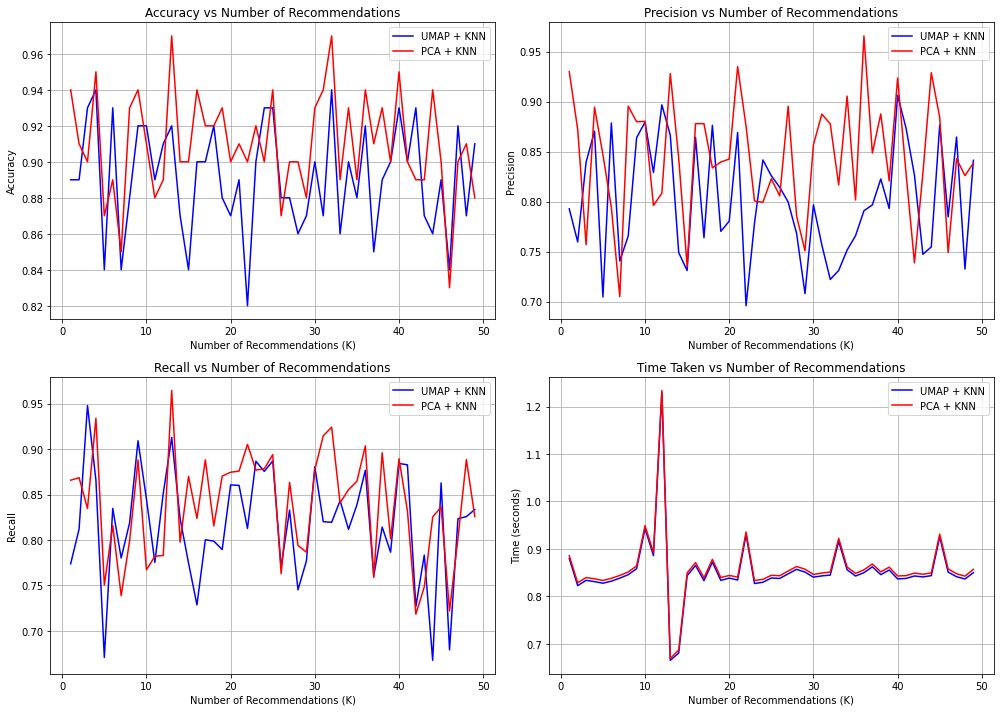

In [341]:
import random
import umap
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- UMAP + KNN ---
# Initialize UMAP and reduce the dimensionality of the features
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize KNN model for UMAP
knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
knn_model_umap.fit(X_umap)

# --- PCA + KNN ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize KNN model for PCA
knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
knn_model_pca.fit(X_pca)

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_umap = []
accuracies_pca = []
precisions_umap = []
precisions_pca = []
recalls_umap = []
recalls_pca = []
times_umap = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []  # Reset for each number of neighbors for UMAP
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_umap = []
    all_true_categories_pca = []
    all_predicted_categories_umap = []
    all_predicted_categories_pca = []
    start_time_umap = time.time()  # Start time for UMAP
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced UMAP space
        query_point_umap = X_umap[i, :].reshape(1, -1)
        
        # Get the indices of the most similar neighbors based on KNN (for UMAP)
        _, indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
        
        # Get recommended categories (excluding the first index which is the input image itself) for UMAP
        recommended_categories_umap = val.loc[indices_umap[0][1:], 'subCategory'].values
        
        # Store the true and predicted categories for UMAP (only considering the first recommendation)
        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])  # Only consider the best recommendation

        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Get the indices of the most similar neighbors based on KNN (for PCA)
        _, indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
        
        # Get recommended categories (excluding the first index which is the input image itself) for PCA
        recommended_categories_pca = val.loc[indices_pca[0][1:], 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the first recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for UMAP + KNN
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap  # Time taken for UMAP
    
    # Calculate metrics for PCA + KNN
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_umap.append(accuracy_umap)
    accuracies_pca.append(accuracy_pca)
    precisions_umap.append(precision_umap)
    precisions_pca.append(precision_pca)
    recalls_umap.append(recall_umap)
    recalls_pca.append(recall_pca)
    times_umap.append(time_taken_umap)
    times_pca.append(time_taken_pca)

# Plotting the accuracy, precision, recall, and time taken for both UMAP + KNN and PCA + KNN
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy Plot
axs[0, 0].plot(num_recommendations_list, accuracies_umap, label="UMAP + KNN", color='b')
axs[0, 0].plot(num_recommendations_list, accuracies_pca, label="PCA + KNN", color='r')
axs[0, 0].set_title('Accuracy vs Number of Recommendations')
axs[0, 0].set_xlabel('Number of Recommendations (K)')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].legend()
axs[0, 0].grid()

# Precision Plot
axs[0, 1].plot(num_recommendations_list, precisions_umap, label="UMAP + KNN", color='b')
axs[0, 1].plot(num_recommendations_list, precisions_pca, label="PCA + KNN", color='r')
axs[0, 1].set_title('Precision vs Number of Recommendations')
axs[0, 1].set_xlabel('Number of Recommendations (K)')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].legend()
axs[0, 1].grid()

# Recall Plot
axs[1, 0].plot(num_recommendations_list, recalls_umap, label="UMAP + KNN", color='b')
axs[1, 0].plot(num_recommendations_list, recalls_pca, label="PCA + KNN", color='r')
axs[1, 0].set_title('Recall vs Number of Recommendations')
axs[1, 0].set_xlabel('Number of Recommendations (K)')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].legend()
axs[1, 0].grid()

# Time Taken Plot
axs[1, 1].plot(num_recommendations_list, times_umap, label="UMAP + KNN", color='b')
axs[1, 1].plot(num_recommendations_list, times_pca, label="PCA + KNN", color='r')
axs[1, 1].set_title('Time Taken vs Number of Recommendations')
axs[1, 1].set_xlabel('Number of Recommendations (K)')
axs[1, 1].set_ylabel('Time (seconds)')
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

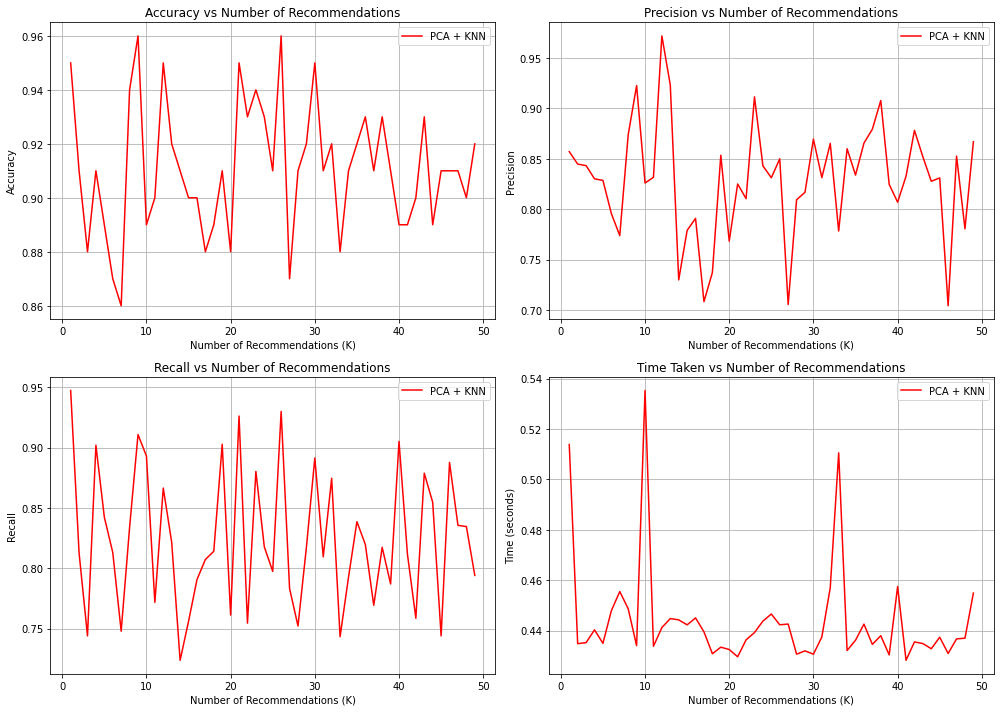

In [342]:
import random
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- PCA + KNN ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize KNN model for PCA
knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
knn_model_pca.fit(X_pca)

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_pca = []
precisions_pca = []
recalls_pca = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Get the indices of the most similar neighbors based on KNN (for PCA)
        _, indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
        
        # Get recommended categories (excluding the first index which is the input image itself) for PCA
        recommended_categories_pca = val.loc[indices_pca[0][1:], 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the first recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for PCA + KNN
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_pca.append(accuracy_pca)
    precisions_pca.append(precision_pca)
    recalls_pca.append(recall_pca)
    times_pca.append(time_taken_pca)

# Plotting the accuracy, precision, recall, and time taken for PCA + KNN
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy Plot
axs[0, 0].plot(num_recommendations_list, accuracies_pca, label="PCA + KNN", color='r')
axs[0, 0].set_title('Accuracy vs Number of Recommendations')
axs[0, 0].set_xlabel('Number of Recommendations (K)')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].legend()
axs[0, 0].grid()

# Precision Plot
axs[0, 1].plot(num_recommendations_list, precisions_pca, label="PCA + KNN", color='r')
axs[0, 1].set_title('Precision vs Number of Recommendations')
axs[0, 1].set_xlabel('Number of Recommendations (K)')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].legend()
axs[0, 1].grid()

# Recall Plot
axs[1, 0].plot(num_recommendations_list, recalls_pca, label="PCA + KNN", color='r')
axs[1, 0].set_title('Recall vs Number of Recommendations')
axs[1, 0].set_xlabel('Number of Recommendations (K)')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].legend()
axs[1, 0].grid()

# Time Taken Plot
axs[1, 1].plot(num_recommendations_list, times_pca, label="PCA + KNN", color='r')
axs[1, 1].set_title('Time Taken vs Number of Recommendations')
axs[1, 1].set_xlabel('Number of Recommendations (K)')
axs[1, 1].set_ylabel('Time (seconds)')
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

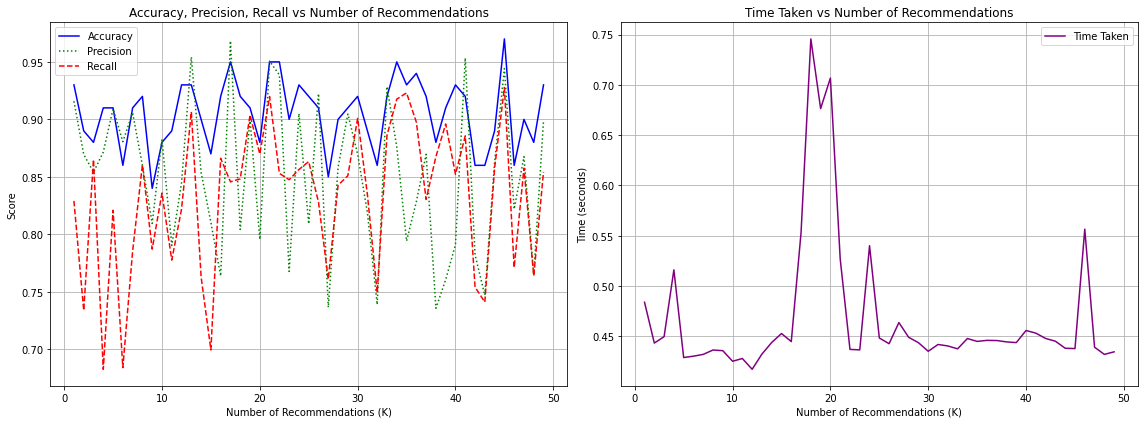

In [343]:
import random
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- PCA + KNN ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize KNN model for PCA
knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')  # Using Euclidean distance
knn_model_pca.fit(X_pca)

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_pca = []
precisions_pca = []
recalls_pca = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Get the indices of the most similar neighbors based on KNN (for PCA)
        _, indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)  # Skip the first index (itself)
        
        # Get recommended categories (excluding the first index which is the input image itself) for PCA
        recommended_categories_pca = val.loc[indices_pca[0][1:], 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the first recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for PCA + KNN
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_pca.append(accuracy_pca)
    precisions_pca.append(precision_pca)
    recalls_pca.append(recall_pca)
    times_pca.append(time_taken_pca)

# Plotting accuracy, precision, and recall in one plot and time taken in another
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Combined Accuracy, Precision, and Recall Plot
axs[0].plot(num_recommendations_list, accuracies_pca, label="Accuracy", color='b', linestyle='-')
axs[0].plot(num_recommendations_list, precisions_pca, label="Precision", color='g', linestyle=':')
axs[0].plot(num_recommendations_list, recalls_pca, label="Recall", color='r', linestyle='--')
axs[0].set_title('Accuracy, Precision, Recall vs Number of Recommendations')
axs[0].set_xlabel('Number of Recommendations (K)')
axs[0].set_ylabel('Score')
axs[0].legend()
axs[0].grid()

# Time Taken Plot
axs[1].plot(num_recommendations_list, times_pca, label="Time Taken", color='purple')
axs[1].set_title('Time Taken vs Number of Recommendations')
axs[1].set_xlabel('Number of Recommendations (K)')
axs[1].set_ylabel('Time (seconds)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

In [344]:
# Define specific recommendation numbers to analyze
specific_recommendations = [10, 20, 30, 40, 50]

# Initialize variables to store averages
avg_accuracy = 0
avg_precision = 0
avg_recall = 0
avg_time = 0

# Loop through specific recommendation numbers and fetch stored metrics
print("Metrics for Specific Recommendations:")
for num_neighbors in specific_recommendations:
    if num_neighbors - 1 < len(accuracies_pca):  # Ensure valid index
        index = num_neighbors - 1  # Adjust for zero-based indexing in lists
        accuracy = accuracies_pca[index]
        precision = precisions_pca[index]
        recall = recalls_pca[index]
        time_taken = times_pca[index]
        
        # Print metrics for the current number of recommendations
        print(f"Recommendations: {num_neighbors}, "
              f"Accuracy: {accuracy:.4f}, "
              f"Precision: {precision:.4f}, "
              f"Recall: {recall:.4f}, "
              f"Time Taken: {time_taken:.4f} seconds")
        
        # Add to averages
        avg_accuracy += accuracy
        avg_precision += precision
        avg_recall += recall
        avg_time += time_taken

# Calculate and print average metrics
avg_accuracy /= len(specific_recommendations)
avg_precision /= len(specific_recommendations)
avg_recall /= len(specific_recommendations)
avg_time /= len(specific_recommendations)

print("\nAverage Metrics:")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average Time Taken: {avg_time:.4f} seconds")


Metrics for Specific Recommendations:
Recommendations: 10, Accuracy: 0.8800, Precision: 0.8827, Recall: 0.8359, Time Taken: 0.4252 seconds
Recommendations: 20, Accuracy: 0.8800, Precision: 0.7957, Recall: 0.8699, Time Taken: 0.7068 seconds
Recommendations: 30, Accuracy: 0.9200, Precision: 0.8698, Recall: 0.9009, Time Taken: 0.4351 seconds
Recommendations: 40, Accuracy: 0.9300, Precision: 0.7910, Recall: 0.8522, Time Taken: 0.4558 seconds

Average Metrics:
Average Accuracy: 0.7220
Average Precision: 0.6678
Average Recall: 0.6918
Average Time Taken: 0.4046 seconds


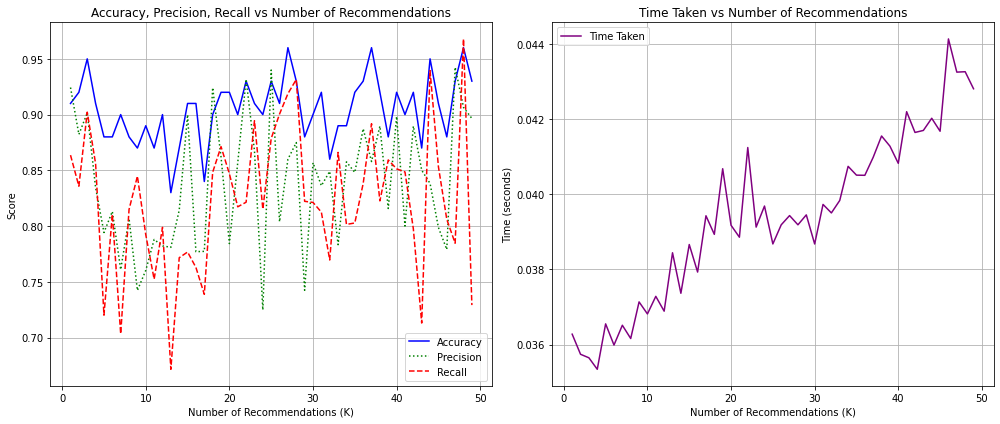

In [345]:
import random
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from annoy import AnnoyIndex
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- PCA + Annoy ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize Annoy index for PCA
f_pca = X_pca.shape[1]  # Number of dimensions after PCA (50)
annoy_index_pca = AnnoyIndex(f_pca, 'angular')
for i in range(len(X_pca)):
    annoy_index_pca.add_item(i, X_pca[i, :])
annoy_index_pca.build(10)  # Building the index (can take some time)

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_pca = []
precisions_pca = []
recalls_pca = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Get the most similar neighbors based on Annoy (PCA space)
        similar_indices_pca = annoy_index_pca.get_nns_by_vector(query_point_pca[0], num_neighbors + 1, include_distances=False)
        
        # Get recommended categories for PCA (excluding the first index which is the input image itself)
        recommended_categories_pca = val.loc[similar_indices_pca[1:], 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the best recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for PCA + Annoy
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_pca.append(accuracy_pca)
    precisions_pca.append(precision_pca)
    recalls_pca.append(recall_pca)
    times_pca.append(time_taken_pca)

# Plotting accuracy, precision, recall, and time taken for PCA + Annoy
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Combined Accuracy, Precision, and Recall Plot
axs[0].plot(num_recommendations_list, accuracies_pca, label="Accuracy", color='b', linestyle='-')
axs[0].plot(num_recommendations_list, precisions_pca, label="Precision", color='g', linestyle=':')
axs[0].plot(num_recommendations_list, recalls_pca, label="Recall", color='r', linestyle='--')
axs[0].set_title('Accuracy, Precision, Recall vs Number of Recommendations')
axs[0].set_xlabel('Number of Recommendations (K)')
axs[0].set_ylabel('Score')
axs[0].legend()
axs[0].grid()

# Time Taken Plot
axs[1].plot(num_recommendations_list, times_pca, label="Time Taken", color='purple')
axs[1].set_title('Time Taken vs Number of Recommendations')
axs[1].set_xlabel('Number of Recommendations (K)')
axs[1].set_ylabel('Time (seconds)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

In [346]:
# Define specific recommendation numbers to analyze
specific_recommendations = [10, 20, 30, 40, 50]

# Initialize variables to store averages
avg_accuracy = 0
avg_precision = 0
avg_recall = 0
avg_time = 0

# Loop through specific recommendation numbers and fetch stored metrics
print("Metrics for Specific Recommendations:")
for num_neighbors in specific_recommendations:
    if num_neighbors - 1 < len(accuracies_pca):  # Ensure valid index
        index = num_neighbors - 1  # Adjust for zero-based indexing in lists
        accuracy = accuracies_pca[index]
        precision = precisions_pca[index]
        recall = recalls_pca[index]
        time_taken = times_pca[index]
        
        # Print metrics for the current number of recommendations
        print(f"Recommendations: {num_neighbors}, "
              f"Accuracy: {accuracy:.4f}, "
              f"Precision: {precision:.4f}, "
              f"Recall: {recall:.4f}, "
              f"Time Taken: {time_taken:.4f} seconds")
        
        # Add to averages
        avg_accuracy += accuracy
        avg_precision += precision
        avg_recall += recall
        avg_time += time_taken

# Calculate and print average metrics
avg_accuracy /= len(specific_recommendations)
avg_precision /= len(specific_recommendations)
avg_recall /= len(specific_recommendations)
avg_time /= len(specific_recommendations)

print("\nAverage Metrics:")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average Time Taken: {avg_time:.4f} seconds")


Metrics for Specific Recommendations:
Recommendations: 10, Accuracy: 0.8900, Precision: 0.7603, Recall: 0.7922, Time Taken: 0.0368 seconds
Recommendations: 20, Accuracy: 0.9200, Precision: 0.7843, Recall: 0.8469, Time Taken: 0.0392 seconds
Recommendations: 30, Accuracy: 0.9000, Precision: 0.8568, Recall: 0.8212, Time Taken: 0.0387 seconds
Recommendations: 40, Accuracy: 0.9200, Precision: 0.8983, Recall: 0.8513, Time Taken: 0.0408 seconds

Average Metrics:
Average Accuracy: 0.7260
Average Precision: 0.6600
Average Recall: 0.6623
Average Time Taken: 0.0311 seconds


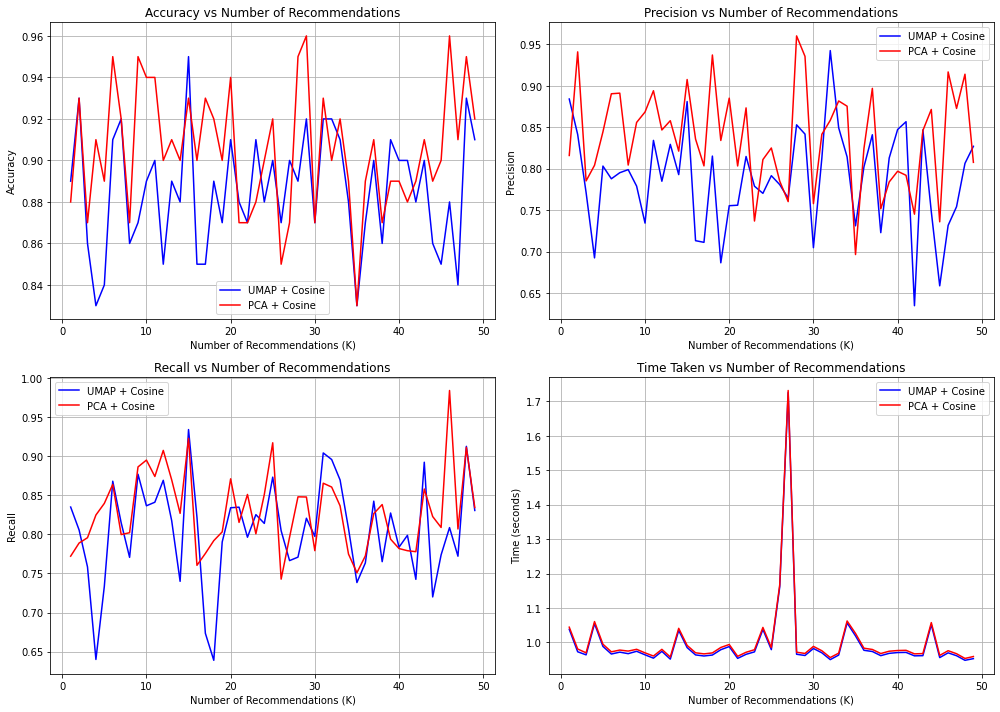

In [347]:
import random
import umap
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- UMAP + Cosine ---
# Initialize UMAP and reduce the dimensionality of the features
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# --- PCA + Cosine ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_umap = []
accuracies_pca = []
precisions_umap = []
precisions_pca = []
recalls_umap = []
recalls_pca = []
times_umap = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []  # Reset for each number of neighbors for UMAP
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_umap = []
    all_true_categories_pca = []
    all_predicted_categories_umap = []
    all_predicted_categories_pca = []
    start_time_umap = time.time()  # Start time for UMAP
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced UMAP space
        query_point_umap = X_umap[i, :].reshape(1, -1)
        
        # Compute cosine similarity between the query point and the entire UMAP dataset
        cosine_similarities_umap = cosine_similarity(query_point_umap, X_umap)
        cosine_similarities_umap = cosine_similarities_umap.flatten()
        
        # Get indices of most similar neighbors based on cosine similarity (excluding itself)
        similar_indices_umap = np.argsort(cosine_similarities_umap)[::-1][1:num_neighbors + 1]  # Skip the first index (itself)
        
        # Get recommended categories for UMAP (excluding the first index which is the input image itself)
        recommended_categories_umap = val.loc[similar_indices_umap, 'subCategory'].values
        
        # Store the true and predicted categories for UMAP (only considering the best recommendation)
        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])  # Only consider the best recommendation

        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Compute cosine similarity between the query point and the entire PCA dataset
        cosine_similarities_pca = cosine_similarity(query_point_pca, X_pca)
        cosine_similarities_pca = cosine_similarities_pca.flatten()
        
        # Get indices of most similar neighbors based on cosine similarity (excluding itself)
        similar_indices_pca = np.argsort(cosine_similarities_pca)[::-1][1:num_neighbors + 1]  # Skip the first index (itself)
        
        # Get recommended categories for PCA (excluding the first index which is the input image itself)
        recommended_categories_pca = val.loc[similar_indices_pca, 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the best recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for UMAP + Cosine
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap  # Time taken for UMAP
    
    # Calculate metrics for PCA + Cosine
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_umap.append(accuracy_umap)
    accuracies_pca.append(accuracy_pca)
    precisions_umap.append(precision_umap)
    precisions_pca.append(precision_pca)
    recalls_umap.append(recall_umap)
    recalls_pca.append(recall_pca)
    times_umap.append(time_taken_umap)
    times_pca.append(time_taken_pca)

# Plotting the accuracy, precision, recall, and time taken for both UMAP + Cosine and PCA + Cosine
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy Plot
axs[0, 0].plot(num_recommendations_list, accuracies_umap, label="UMAP + Cosine", color='b')
axs[0, 0].plot(num_recommendations_list, accuracies_pca, label="PCA + Cosine", color='r')
axs[0, 0].set_title('Accuracy vs Number of Recommendations')
axs[0, 0].set_xlabel('Number of Recommendations (K)')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].legend()
axs[0, 0].grid()

# Precision Plot
axs[0, 1].plot(num_recommendations_list, precisions_umap, label="UMAP + Cosine", color='b')
axs[0, 1].plot(num_recommendations_list, precisions_pca, label="PCA + Cosine", color='r')
axs[0, 1].set_title('Precision vs Number of Recommendations')
axs[0, 1].set_xlabel('Number of Recommendations (K)')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].legend()
axs[0, 1].grid()

# Recall Plot
axs[1, 0].plot(num_recommendations_list, recalls_umap, label="UMAP + Cosine", color='b')
axs[1, 0].plot(num_recommendations_list, recalls_pca, label="PCA + Cosine", color='r')
axs[1, 0].set_title('Recall vs Number of Recommendations')
axs[1, 0].set_xlabel('Number of Recommendations (K)')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].legend()
axs[1, 0].grid()

# Time Taken Plot
axs[1, 1].plot(num_recommendations_list, times_umap, label="UMAP + Cosine", color='b')
axs[1, 1].plot(num_recommendations_list, times_pca, label="PCA + Cosine", color='r')
axs[1, 1].set_title('Time Taken vs Number of Recommendations')
axs[1, 1].set_xlabel('Number of Recommendations (K)')
axs[1, 1].set_ylabel('Time (seconds)')
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

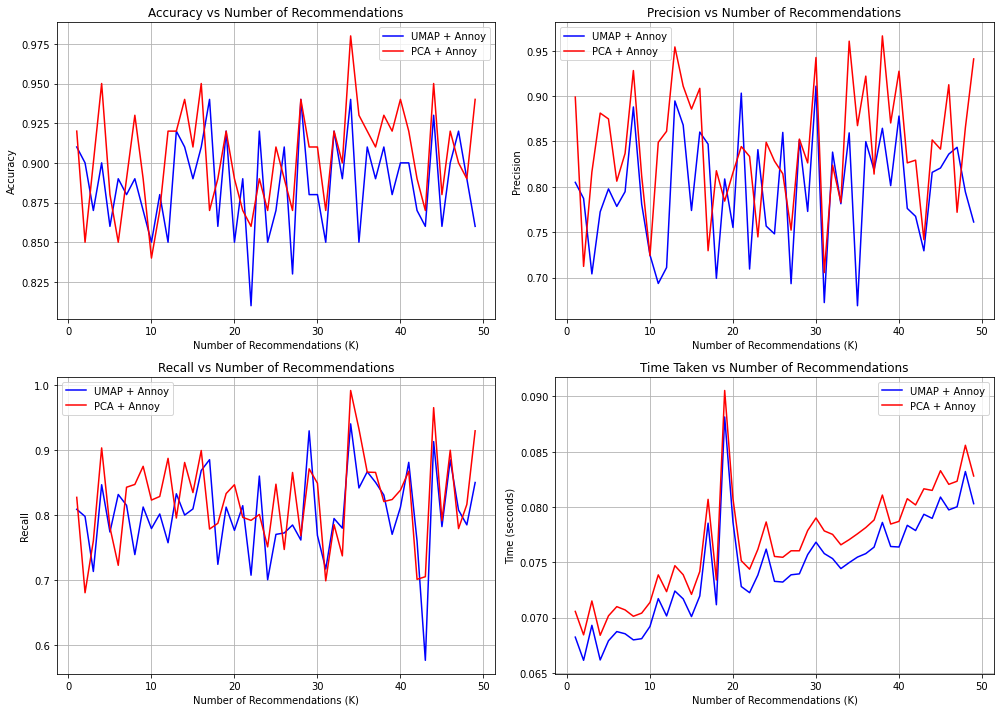

In [348]:
import random
import umap
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from annoy import AnnoyIndex
from sklearn.metrics import precision_score, recall_score, accuracy_score
import time
import matplotlib.pyplot as plt

# Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# X is the combined feature matrix (num_samples x num_features)
# 'subCategory' is the true category in the validation set

# --- UMAP + Annoy ---
# Initialize UMAP and reduce the dimensionality of the features
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
X_umap = umap_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize Annoy index for UMAP
f_umap = X_umap.shape[1]  # Number of dimensions after UMAP (50)
annoy_index_umap = AnnoyIndex(f_umap, 'angular')
for i in range(len(X_umap)):
    annoy_index_umap.add_item(i, X_umap[i, :])
annoy_index_umap.build(10)  # Building the index (can take some time)

# --- PCA + Annoy ---
# Initialize PCA and reduce the dimensionality of the features
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)  # Fit and transform the features into lower dimensional space

# Initialize Annoy index for PCA
f_pca = X_pca.shape[1]  # Number of dimensions after PCA (50)
annoy_index_pca = AnnoyIndex(f_pca, 'angular')
for i in range(len(X_pca)):
    annoy_index_pca.add_item(i, X_pca[i, :])
annoy_index_pca.build(10)  # Building the index (can take some time)

# Initialize lists to store the number of recommendations and their corresponding metrics
num_recommendations_list = []
accuracies_umap = []
accuracies_pca = []
precisions_umap = []
precisions_pca = []
recalls_umap = []
recalls_pca = []
times_umap = []
times_pca = []

# Define the range of neighbors to test
neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# Number of samples to evaluate
num_samples = 100

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []  # Reset for each number of neighbors for UMAP
    correct_recommendations_pca = []  # Reset for each number of neighbors for PCA
    all_true_categories_umap = []
    all_true_categories_pca = []
    all_predicted_categories_umap = []
    all_predicted_categories_pca = []
    start_time_umap = time.time()  # Start time for UMAP
    start_time_pca = time.time()  # Start time for PCA
    
    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)  # Random index from validation set
        true_category = val.loc[i, 'subCategory']  # Actual subCategory of the input image
        
        # Get the query sample in the reduced UMAP space
        query_point_umap = X_umap[i, :].reshape(1, -1)
        
        # Get the most similar neighbors based on Annoy (UMAP space)
        similar_indices_umap = annoy_index_umap.get_nns_by_vector(query_point_umap[0], num_neighbors + 1, include_distances=False)
        
        # Get recommended categories for UMAP (excluding the first index which is the input image itself)
        recommended_categories_umap = val.loc[similar_indices_umap[1:], 'subCategory'].values
        
        # Store the true and predicted categories for UMAP (only considering the best recommendation)
        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])  # Only consider the best recommendation

        # Get the query sample in the reduced PCA space
        query_point_pca = X_pca[i, :].reshape(1, -1)
        
        # Get the most similar neighbors based on Annoy (PCA space)
        similar_indices_pca = annoy_index_pca.get_nns_by_vector(query_point_pca[0], num_neighbors + 1, include_distances=False)
        
        # Get recommended categories for PCA (excluding the first index which is the input image itself)
        recommended_categories_pca = val.loc[similar_indices_pca[1:], 'subCategory'].values
        
        # Store the true and predicted categories for PCA (only considering the best recommendation)
        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])  # Only consider the best recommendation

    # Calculate metrics for UMAP + Annoy
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap  # Time taken for UMAP
    
    # Calculate metrics for PCA + Annoy
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca  # Time taken for PCA
    
    # Store the results
    num_recommendations_list.append(num_neighbors)
    accuracies_umap.append(accuracy_umap)
    accuracies_pca.append(accuracy_pca)
    precisions_umap.append(precision_umap)
    precisions_pca.append(precision_pca)
    recalls_umap.append(recall_umap)
    recalls_pca.append(recall_pca)
    times_umap.append(time_taken_umap)
    times_pca.append(time_taken_pca)

# Plotting the accuracy, precision, recall, and time taken for both UMAP + Annoy and PCA + Annoy
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy Plot
axs[0, 0].plot(num_recommendations_list, accuracies_umap, label="UMAP + Annoy", color='b')
axs[0, 0].plot(num_recommendations_list, accuracies_pca, label="PCA + Annoy", color='r')
axs[0, 0].set_title('Accuracy vs Number of Recommendations')
axs[0, 0].set_xlabel('Number of Recommendations (K)')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].legend()
axs[0, 0].grid()

# Precision Plot
axs[0, 1].plot(num_recommendations_list, precisions_umap, label="UMAP + Annoy", color='b')
axs[0, 1].plot(num_recommendations_list, precisions_pca, label="PCA + Annoy", color='r')
axs[0, 1].set_title('Precision vs Number of Recommendations')
axs[0, 1].set_xlabel('Number of Recommendations (K)')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].legend()
axs[0, 1].grid()

# Recall Plot
axs[1, 0].plot(num_recommendations_list, recalls_umap, label="UMAP + Annoy", color='b')
axs[1, 0].plot(num_recommendations_list, recalls_pca, label="PCA + Annoy", color='r')
axs[1, 0].set_title('Recall vs Number of Recommendations')
axs[1, 0].set_xlabel('Number of Recommendations (K)')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].legend()
axs[1, 0].grid()

# Time Taken Plot
axs[1, 1].plot(num_recommendations_list, times_umap, label="UMAP + Annoy", color='b')
axs[1, 1].plot(num_recommendations_list, times_pca, label="PCA + Annoy", color='r')
axs[1, 1].set_title('Time Taken vs Number of Recommendations')
axs[1, 1].set_xlabel('Number of Recommendations (K)')
axs[1, 1].set_ylabel('Time (seconds)')
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()


In [349]:
# import random
# import umap
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.neighbors import NearestNeighbors
# from sklearn.metrics import precision_score, recall_score, accuracy_score
# from sklearn.metrics.pairwise import cosine_similarity
# from annoy import AnnoyIndex
# import time
# import matplotlib.pyplot as plt

# # Assuming 'X' is the combined feature matrix (image + text features) and 'val' is the validation set
# # X is the combined feature matrix (num_samples x num_features)
# # 'subCategory' is the true category in the validation set

# # Initialize metrics dictionary
# metrics = {
#     'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'UMAP + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
#     'PCA + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []}
# }

# # Define the range of neighbors to test
# neighbor_values = range(1, 50)  # Testing 1 to 50 recommendations

# # Number of samples to evaluate
# num_samples = 100

# # --- UMAP + Cosine ---
# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
# X_umap = umap_model.fit_transform(X)

# for num_neighbors in neighbor_values:
#     correct_recommendations_umap = []
#     all_true_categories_umap = []
#     all_predicted_categories_umap = []
#     start_time_umap = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_umap = X_umap[i, :].reshape(1, -1)

#         # Calculate cosine similarities
#         similarities_umap = cosine_similarity(query_point_umap, X_umap)
#         sorted_indices_umap = np.argsort(-similarities_umap[0])  # Get indices sorted by descending similarity

#         # Get recommended categories
#         recommended_categories_umap = val.loc[sorted_indices_umap[1:num_neighbors+1], 'subCategory'].values

#         all_true_categories_umap.append(true_category)
#         all_predicted_categories_umap.append(recommended_categories_umap[0])

#     # Calculate metrics for UMAP + Cosine
#     accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
#     precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     time_taken_umap = time.time() - start_time_umap

#     metrics['UMAP + Cosine']['accuracy'].append(accuracy_umap)
#     metrics['UMAP + Cosine']['precision'].append(precision_umap)
#     metrics['UMAP + Cosine']['recall'].append(recall_umap)
#     metrics['UMAP + Cosine']['time'].append(time_taken_umap)

# # --- PCA + Cosine ---
# pca_model = PCA(n_components=50)
# X_pca = pca_model.fit_transform(X)

# for num_neighbors in neighbor_values:
#     correct_recommendations_pca = []
#     all_true_categories_pca = []
#     all_predicted_categories_pca = []
#     start_time_pca = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_pca = X_pca[i, :].reshape(1, -1)

#         # Calculate cosine similarities
#         similarities_pca = cosine_similarity(query_point_pca, X_pca)
#         sorted_indices_pca = np.argsort(-similarities_pca[0])

#         # Get recommended categories
#         recommended_categories_pca = val.loc[sorted_indices_pca[1:num_neighbors+1], 'subCategory'].values

#         all_true_categories_pca.append(true_category)
#         all_predicted_categories_pca.append(recommended_categories_pca[0])

#     # Calculate metrics for PCA + Cosine
#     accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
#     precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     time_taken_pca = time.time() - start_time_pca

#     metrics['PCA + Cosine']['accuracy'].append(accuracy_pca)
#     metrics['PCA + Cosine']['precision'].append(precision_pca)
#     metrics['PCA + Cosine']['recall'].append(recall_pca)
#     metrics['PCA + Cosine']['time'].append(time_taken_pca)

# # --- UMAP + KNN ---
# knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')
# knn_model_umap.fit(X_umap)

# for num_neighbors in neighbor_values:
#     correct_recommendations_umap = []
#     all_true_categories_umap = []
#     all_predicted_categories_umap = []
#     start_time_umap = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_umap = X_umap[i, :].reshape(1, -1)

#         # Get neighbors from KNN
#         _, indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)
#         recommended_categories_umap = val.loc[indices_umap[0][1:], 'subCategory'].values

#         all_true_categories_umap.append(true_category)
#         all_predicted_categories_umap.append(recommended_categories_umap[0])

#     # Calculate metrics for UMAP + KNN
#     accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
#     precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     time_taken_umap = time.time() - start_time_umap

#     metrics['UMAP + KNN']['accuracy'].append(accuracy_umap)
#     metrics['UMAP + KNN']['precision'].append(precision_umap)
#     metrics['UMAP + KNN']['recall'].append(recall_umap)
#     metrics['UMAP + KNN']['time'].append(time_taken_umap)

# # --- PCA + KNN ---
# knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')
# knn_model_pca.fit(X_pca)

# for num_neighbors in neighbor_values:
#     correct_recommendations_pca = []
#     all_true_categories_pca = []
#     all_predicted_categories_pca = []
#     start_time_pca = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_pca = X_pca[i, :].reshape(1, -1)

#         # Get neighbors from KNN
#         _, indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)
#         recommended_categories_pca = val.loc[indices_pca[0][1:], 'subCategory'].values

#         all_true_categories_pca.append(true_category)
#         all_predicted_categories_pca.append(recommended_categories_pca[0])

#     # Calculate metrics for PCA + KNN
#     accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
#     precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     time_taken_pca = time.time() - start_time_pca

#     metrics['PCA + KNN']['accuracy'].append(accuracy_pca)
#     metrics['PCA + KNN']['precision'].append(precision_pca)
#     metrics['PCA + KNN']['recall'].append(recall_pca)
#     metrics['PCA + KNN']['time'].append(time_taken_pca)

# # --- UMAP + Annoy ---
# f_umap = X_umap.shape[1]
# annoy_model_umap = AnnoyIndex(f_umap, 'angular')

# for i in range(len(X_umap)):
#     annoy_model_umap.add_item(i, X_umap[i])

# annoy_model_umap.build(10)

# for num_neighbors in neighbor_values:
#     correct_recommendations_umap = []
#     all_true_categories_umap = []
#     all_predicted_categories_umap = []
#     start_time_umap = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_umap = X_umap[i, :]

#         # Get neighbors from Annoy
#         indices_umap = annoy_model_umap.get_nns_by_vector(query_point_umap, num_neighbors + 1)[1:]
#         recommended_categories_umap = val.loc[indices_umap, 'subCategory'].values

#         all_true_categories_umap.append(true_category)
#         all_predicted_categories_umap.append(recommended_categories_umap[0])

#     # Calculate metrics for UMAP + Annoy
#     accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
#     precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
#     time_taken_umap = time.time() - start_time_umap

#     metrics['UMAP + Annoy']['accuracy'].append(accuracy_umap)
#     metrics['UMAP + Annoy']['precision'].append(precision_umap)
#     metrics['UMAP + Annoy']['recall'].append(recall_umap)
#     metrics['UMAP + Annoy']['time'].append(time_taken_umap)

# # --- PCA + Annoy ---
# f_pca = X_pca.shape[1]
# annoy_model_pca = AnnoyIndex(f_pca, 'angular')

# for i in range(len(X_pca)):
#     annoy_model_pca.add_item(i, X_pca[i])

# annoy_model_pca.build(10)

# for num_neighbors in neighbor_values:
#     correct_recommendations_pca = []
#     all_true_categories_pca = []
#     all_predicted_categories_pca = []
#     start_time_pca = time.time()

#     for _ in range(num_samples):
#         i = random.randint(0, len(val) - 1)
#         true_category = val.loc[i, 'subCategory']
#         query_point_pca = X_pca[i, :]

#         # Get neighbors from Annoy
#         indices_pca = annoy_model_pca.get_nns_by_vector(query_point_pca, num_neighbors + 1)[1:]
#         recommended_categories_pca = val.loc[indices_pca, 'subCategory'].values

#         all_true_categories_pca.append(true_category)
#         all_predicted_categories_pca.append(recommended_categories_pca[0])

#     # Calculate metrics for PCA + Annoy
#     accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
#     precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
#     time_taken_pca = time.time() - start_time_pca

#     metrics['PCA + Annoy']['accuracy'].append(accuracy_pca)
#     metrics['PCA + Annoy']['precision'].append(precision_pca)
#     metrics['PCA + Annoy']['recall'].append(recall_pca)
#     metrics['PCA + Annoy']['time'].append(time_taken_pca)

# # Plot the metrics for all models
# plt.figure(figsize=(12, 12))
# for i, metric in enumerate(['accuracy', 'precision', 'recall', 'time']):
#     plt.subplot(2, 2, i + 1)
#     for method in metrics.keys():
#         plt.plot(neighbor_values, metrics[method][metric], label=method)
#     plt.title(f'{metric.capitalize()} vs. Number of Neighbors')
#     plt.xlabel('Number of Neighbors')
#     plt.ylabel(metric.capitalize())
#     plt.legend()
#     plt.grid()

# plt.tight_layout()
# plt.show()


In [350]:
# Calculate and print average metrics for each method
for method, method_metrics in metrics.items():
    avg_accuracy = np.mean(method_metrics['accuracy'])
    avg_precision = np.mean(method_metrics['precision'])
    avg_recall = np.mean(method_metrics['recall'])
    avg_time = np.mean(method_metrics['time'])
    
    print(f"{method} - Average Accuracy: {avg_accuracy:.4f}")
    print(f"{method} - Average Precision: {avg_precision:.4f}")
    print(f"{method} - Average Recall: {avg_recall:.4f}")
    print(f"{method} - Average Time: {avg_time:.4f} seconds")
    print("-" * 50)


UMAP + Cosine - Average Accuracy: 0.8160
UMAP + Cosine - Average Precision: 0.7082
UMAP + Cosine - Average Recall: 0.6530
UMAP + Cosine - Average Time: 0.1682 seconds
--------------------------------------------------
UMAP + KNN - Average Accuracy: 0.8560
UMAP + KNN - Average Precision: 0.7870
UMAP + KNN - Average Recall: 0.7563
UMAP + KNN - Average Time: 0.1840 seconds
--------------------------------------------------
PCA + Cosine - Average Accuracy: 0.8660
PCA + Cosine - Average Precision: 0.8176
PCA + Cosine - Average Recall: 0.7806
PCA + Cosine - Average Time: 0.1817 seconds
--------------------------------------------------
PCA + KNN - Average Accuracy: 0.8820
PCA + KNN - Average Precision: 0.8496
PCA + KNN - Average Recall: 0.7760
PCA + KNN - Average Time: 0.1881 seconds
--------------------------------------------------
UMAP + Annoy - Average Accuracy: 0.8280
UMAP + Annoy - Average Precision: 0.6672
UMAP + Annoy - Average Recall: 0.7435
UMAP + Annoy - Average Time: 0.0474 secon

In [351]:
import random
import umap
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from annoy import AnnoyIndex
import time

# Initialize metrics dictionary
metrics = {
    'UMAP + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
    'UMAP + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
    'PCA + Cosine': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
    'PCA + KNN': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
    'UMAP + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []},
    'PCA + Annoy': {'accuracy': [], 'precision': [], 'recall': [], 'time': []}
}

# Define the range of neighbors to test
neighbor_values = [10, 20, 30, 40, 50]  # 10 to 50 recommendations
num_samples = 100  # Number of samples to evaluate

# --- UMAP + Cosine ---
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=50, random_state=42)
X_umap = umap_model.fit_transform(X)

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []
    all_true_categories_umap = []
    all_predicted_categories_umap = []
    start_time_umap = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_umap = X_umap[i, :].reshape(1, -1)

        # Calculate cosine similarities
        similarities_umap = cosine_similarity(query_point_umap, X_umap)
        sorted_indices_umap = np.argsort(-similarities_umap[0])

        # Get recommended categories
        recommended_categories_umap = val.loc[sorted_indices_umap[1:num_neighbors+1], 'subCategory'].values

        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])

    # Calculate metrics for UMAP + Cosine
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap

    metrics['UMAP + Cosine']['accuracy'].append(accuracy_umap)
    metrics['UMAP + Cosine']['precision'].append(precision_umap)
    metrics['UMAP + Cosine']['recall'].append(recall_umap)
    metrics['UMAP + Cosine']['time'].append(time_taken_umap)

# --- PCA + Cosine ---
pca_model = PCA(n_components=50)
X_pca = pca_model.fit_transform(X)

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_pca = X_pca[i, :].reshape(1, -1)

        # Calculate cosine similarities
        similarities_pca = cosine_similarity(query_point_pca, X_pca)
        sorted_indices_pca = np.argsort(-similarities_pca[0])

        # Get recommended categories
        recommended_categories_pca = val.loc[sorted_indices_pca[1:num_neighbors+1], 'subCategory'].values

        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])

    # Calculate metrics for PCA + Cosine
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca

    metrics['PCA + Cosine']['accuracy'].append(accuracy_pca)
    metrics['PCA + Cosine']['precision'].append(precision_pca)
    metrics['PCA + Cosine']['recall'].append(recall_pca)
    metrics['PCA + Cosine']['time'].append(time_taken_pca)

# --- UMAP + KNN ---
knn_model_umap = NearestNeighbors(n_neighbors=50, metric='euclidean')
knn_model_umap.fit(X_umap)

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []
    all_true_categories_umap = []
    all_predicted_categories_umap = []
    start_time_umap = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_umap = X_umap[i, :].reshape(1, -1)

        # Get neighbors from KNN
        _, indices_umap = knn_model_umap.kneighbors(query_point_umap, n_neighbors=num_neighbors + 1)
        recommended_categories_umap = val.loc[indices_umap[0][1:], 'subCategory'].values

        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])

    # Calculate metrics for UMAP + KNN
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap

    metrics['UMAP + KNN']['accuracy'].append(accuracy_umap)
    metrics['UMAP + KNN']['precision'].append(precision_umap)
    metrics['UMAP + KNN']['recall'].append(recall_umap)
    metrics['UMAP + KNN']['time'].append(time_taken_umap)

# --- PCA + KNN ---
knn_model_pca = NearestNeighbors(n_neighbors=50, metric='euclidean')
knn_model_pca.fit(X_pca)

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_pca = X_pca[i, :].reshape(1, -1)

        # Get neighbors from KNN
        _, indices_pca = knn_model_pca.kneighbors(query_point_pca, n_neighbors=num_neighbors + 1)
        recommended_categories_pca = val.loc[indices_pca[0][1:], 'subCategory'].values

        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])

    # Calculate metrics for PCA + KNN
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca

    metrics['PCA + KNN']['accuracy'].append(accuracy_pca)
    metrics['PCA + KNN']['precision'].append(precision_pca)
    metrics['PCA + KNN']['recall'].append(recall_pca)
    metrics['PCA + KNN']['time'].append(time_taken_pca)

# --- UMAP + Annoy ---
f_umap = X_umap.shape[1]
annoy_model_umap = AnnoyIndex(f_umap, 'angular')

for i in range(len(X_umap)):
    annoy_model_umap.add_item(i, X_umap[i])

annoy_model_umap.build(10)

for num_neighbors in neighbor_values:
    correct_recommendations_umap = []
    all_true_categories_umap = []
    all_predicted_categories_umap = []
    start_time_umap = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_umap = X_umap[i, :]

        # Get neighbors from Annoy
        indices_umap = annoy_model_umap.get_nns_by_vector(query_point_umap, num_neighbors + 1)[1:]
        recommended_categories_umap = val.loc[indices_umap, 'subCategory'].values

        all_true_categories_umap.append(true_category)
        all_predicted_categories_umap.append(recommended_categories_umap[0])

    # Calculate metrics for UMAP + Annoy
    accuracy_umap = accuracy_score(all_true_categories_umap, all_predicted_categories_umap)
    precision_umap = precision_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    recall_umap = recall_score(all_true_categories_umap, all_predicted_categories_umap, average='macro', zero_division=1)
    time_taken_umap = time.time() - start_time_umap

    metrics['UMAP + Annoy']['accuracy'].append(accuracy_umap)
    metrics['UMAP + Annoy']['precision'].append(precision_umap)
    metrics['UMAP + Annoy']['recall'].append(recall_umap)
    metrics['UMAP + Annoy']['time'].append(time_taken_umap)

# --- PCA + Annoy ---
f_pca = X_pca.shape[1]
annoy_model_pca = AnnoyIndex(f_pca, 'angular')

for i in range(len(X_pca)):
    annoy_model_pca.add_item(i, X_pca[i])

annoy_model_pca.build(10)

for num_neighbors in neighbor_values:
    correct_recommendations_pca = []
    all_true_categories_pca = []
    all_predicted_categories_pca = []
    start_time_pca = time.time()

    for _ in range(num_samples):
        i = random.randint(0, len(val) - 1)
        true_category = val.loc[i, 'subCategory']
        query_point_pca = X_pca[i, :]

        # Get neighbors from Annoy
        indices_pca = annoy_model_pca.get_nns_by_vector(query_point_pca, num_neighbors + 1)[1:]
        recommended_categories_pca = val.loc[indices_pca, 'subCategory'].values

        all_true_categories_pca.append(true_category)
        all_predicted_categories_pca.append(recommended_categories_pca[0])

    # Calculate metrics for PCA + Annoy
    accuracy_pca = accuracy_score(all_true_categories_pca, all_predicted_categories_pca)
    precision_pca = precision_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    recall_pca = recall_score(all_true_categories_pca, all_predicted_categories_pca, average='macro', zero_division=1)
    time_taken_pca = time.time() - start_time_pca

    metrics['PCA + Annoy']['accuracy'].append(accuracy_pca)
    metrics['PCA + Annoy']['precision'].append(precision_pca)
    metrics['PCA + Annoy']['recall'].append(recall_pca)
    metrics['PCA + Annoy']['time'].append(time_taken_pca)

# Show the metrics for 10, 20, 30, 40, 50 recommendations, including average values
print("\nSummary of Metrics (Accuracy, Precision, Recall, Time) for Different Number of Recommendations:")

summary_df = pd.DataFrame()

for method in metrics.keys():
    avg_accuracy = np.mean(metrics[method]['accuracy'])
    avg_precision = np.mean(metrics[method]['precision'])
    avg_recall = np.mean(metrics[method]['recall'])
    avg_time = np.mean(metrics[method]['time'])
    
    summary_df = summary_df.append({
        'Method': method,
        '10 Recommendations': metrics[method]['accuracy'][0],  # Accuracy for 10 recommendations
        '20 Recommendations': metrics[method]['accuracy'][1],  # Accuracy for 20 recommendations
        '30 Recommendations': metrics[method]['accuracy'][2],  # Accuracy for 30 recommendations
        '40 Recommendations': metrics[method]['accuracy'][3],  # Accuracy for 40 recommendations
        '50 Recommendations': metrics[method]['accuracy'][4],  # Accuracy for 50 recommendations
        'Average Accuracy': avg_accuracy,
        'Average Precision': avg_precision,
        'Average Recall': avg_recall,
        'Average Time': avg_time
    }, ignore_index=True)

print(summary_df)



Summary of Metrics (Accuracy, Precision, Recall, Time) for Different Number of Recommendations:
          Method  10 Recommendations  20 Recommendations  30 Recommendations  \
0  UMAP + Cosine                0.90                0.90                0.89   
1     UMAP + KNN                0.87                0.90                0.90   
2   PCA + Cosine                0.87                0.91                0.91   
3      PCA + KNN                0.93                0.87                0.84   
4   UMAP + Annoy                0.94                0.88                0.94   
5    PCA + Annoy                0.89                0.89                0.88   

   40 Recommendations  50 Recommendations  Average Accuracy  \
0                0.88                0.84             0.882   
1                0.85                0.84             0.872   
2                0.87                0.87             0.886   
3                0.93                0.90             0.894   
4                0.81      

In [352]:
# import matplotlib.pyplot as plt

# # Plotting function for the metrics
# def plot_metrics(metrics, metric_name, y_label):
#     plt.figure(figsize=(10, 6))

#     # Plot each method's metric for the different neighbor values (10, 20, 30, 40, 50 recommendations)
#     for method in metrics.keys():
#         plt.plot(neighbor_values, metrics[method][metric_name], label=method, marker='o')

#     plt.title(f'{metric_name} for Different Methods')
#     plt.xlabel('Number of Recommendations')
#     plt.ylabel(y_label)
#     plt.xticks(neighbor_values)
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# # Plot Accuracy, Precision, Recall, and Time
# plot_metrics(metrics, 'accuracy', 'Accuracy')
# plot_metrics(metrics, 'precision', 'Precision')
# plot_metrics(metrics, 'recall', 'Recall')
# plot_metrics(metrics, 'time', 'Time (seconds)')
